# Analysing alpha-values over different seeds

This notebook is used to gain insights into how varying alpha values changes the dynamics of the problem and influences decision making

It is structured as follows:
1) Initial setup, imports and loading of data
2) Demand patterns and state insight
3) Trip requests
3) Failed events hourly patterns
4) Vehicle activity decision insights and time allocation
5) Comparison of alpha values



# 1 Initial setup, imports and loading of data

Her endrer du current path og seed path, disse er for rough values og fine tuning av verdier

Du kan sette alpha value, som avgjør hvilke filer den henter inn

Selection mode tilsier hvordan du lnsker å laste inn resultatene, som enkelt, average eller alle seeds

### Imports

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gzip
import json
import folium
import numpy as np
import matplotlib.ticker as ticker
import re
from pathlib import Path


### Loading files

In [18]:
import pandas as pd
import json
import gzip
import re
from pathlib import Path
 
# ---------------------------
# 1. ROBUST RELATIVE PATH SETUP
# ---------------------------
 
def find_project_root(start_path: Path) -> Path:
    """
    Searches up the directory tree to find the project root
    by looking for the 'instances' folder.
    """
    # Check current folder and all parents
    for parent in [start_path] + list(start_path.parents):
        if (parent / "instances").exists():
            return parent
   
    # Fallback: Just return the current working directory if not found
    print("Warning: Could not auto-detect project root (looking for 'instances' folder). Using CWD.")
    return start_path
 
# 1. Detect Root
project_root = find_project_root(Path.cwd())
print(f"Project Root detected at: {project_root}")
 
# 2. Define Experiment Settings
policy_name = "sjovik_sund"
experiment_folder = "Benchmark_nightly" # Rough_result_000125  Benchmark_nightly FINAL
 
# 3. Construct Paths Relative to Root
results_dir_root = project_root / "policies" / policy_name / "simulation_results" / experiment_folder
instance_path = project_root / "instances" / "TD_W34_old.json.gz"
 
# (Optional) Verify paths exist to help debug
if not results_dir_root.exists():
    print(f"CRITICAL WARNING: Results directory not found at: {results_dir_root}")
if not instance_path.exists():
    print(f"CRITICAL WARNING: Instance file not found at: {instance_path}")
 
 
# ---------------------------
# 2. CONFIGURATION
# ---------------------------
 
# LIST of Alphas to compare
#alpha_values = [0.22,0.24,0.25,0.26,0.28]  # Legg til dine alpha-verdier her, f.eks [0.24, 0.26]
alpha_values = [0.0]  # Legg til dine alpha-verdier her, f.eks [0.24, 0.26]
#alpha_values = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9] Broad
 
# SELECT MODE: "average" or specific seed integer (e.g., 1)
selection_mode = "average"
 
CAP_AT_DAY_4 = True
 
# ---------------------------
# 3. HELPER FUNCTIONS
# ---------------------------

def apply_time_cap(df):
    """
    Filters the dataframe to cap at Day 4, Hour 1 if CAP_AT_DAY_4 is True.
    Returns the filtered dataframe (or original if CAP_AT_DAY_4 is False).
    Assumes dataframe has 'Day' and 'Hour' columns.
    """
    if not CAP_AT_DAY_4:
        return df
    
    # Filter to keep only data up to Day 5, Hour 1
    return df[(df['Day'] < 5) | ((df['Day'] == 5) & (df['Hour'] <= 1))]
 
def get_result_file(kind: str, seed: int, alpha_s: str) -> Path:
    """
    Finds the specific file with flexible pattern matching.
    Matches the alpha VALUE (e.g. 0.240), the 'kind' (e.g. hourly), and the seed.
    """
    # FIX: Fjernet "alpha_" prefix for å matche filnavn som "...fullweek_0.240_results..."
    pattern = f"*fullweek_{alpha_s}_results_{kind}_seed_{seed}*"
   
    matches = list(results_dir_root.glob(pattern))
   
    if not matches:
        print(f"DEBUG: Looking in {results_dir_root}")
        print(f"DEBUG: Pattern was {pattern}")
        raise FileNotFoundError(f"No file found matching kind '{kind}' for seed {seed} and alpha {alpha_s}")
   
    return matches[0]
 
def get_available_seeds(alpha_s: str) -> list[int]:
    """Scans the folder to find all seed numbers for the given alpha."""
   
    # FIX: Mer fleksibelt søk som finner tallet (f.eks 0.240) uavhengig av prefix
    pattern = f"*{alpha_s}_results_*_seed_*"
    matches = list(results_dir_root.glob(pattern))
   
    seeds = []
    for p in matches:
        # Regex som finner "seed_" etterfulgt av tall
        match = re.search(r"seed_(\d+)", p.name)
        if match:
            seeds.append(int(match.group(1)))
   
    unique_seeds = sorted(list(set(seeds)))
   
    if not unique_seeds:
        print(f"DEBUG: No seeds found using pattern: {pattern}")
    else:
        print(f"DEBUG: Found seeds for alpha {alpha_s}: {unique_seeds}")
       
    return unique_seeds
 
def load_single_seed(seed: int, alpha_s: str) -> dict:
    """Loads all 4 dataframes for a specific seed/alpha combo."""
    return {
        "vehicle": pd.read_csv(get_result_file("vehicle_visits", seed, alpha_s)),
        "hourly": pd.read_csv(get_result_file("hourly", seed, alpha_s)),
        "station_hourly": pd.read_csv(get_result_file("station_hourly", seed, alpha_s)),
        "trip_requests": pd.read_csv(get_result_file("trip_requests", seed, alpha_s))
    }
 
# ---------------------------
# 4. MAIN LOADING LOOP
# ---------------------------
 
# Dictionary to store results for each alpha
alpha_results = {}
 
print(f"Starting comparison for alphas: {alpha_values} | Mode: {selection_mode}")
 
for current_alpha in alpha_values:
    # Format alpha string
    alpha_str = f"{current_alpha:.3f}"
    print(f"\n--- Processing Alpha: {alpha_str} ---")
   
    # 1. Identify seeds for THIS alpha
    available_seeds = get_available_seeds(alpha_str)
   
    if not available_seeds:
        print(f"WARNING: No seeds found for alpha {alpha_str}. Skipping.")
        continue
 
    # 2. Load Data based on selection_mode
    current_alpha_data = {}
 
    # --- MODE: AVERAGE (Calculate mean across seeds) ---
    if selection_mode == "average":
        print(f"   -> Calculating Average over {len(available_seeds)} seeds...")
       
        hourly_list = []
        station_hourly_list = []
        vehicle_list = []
        trip_list = []
 
        for seed in available_seeds:
            data = load_single_seed(seed, alpha_str)
            hourly_list.append(data["hourly"])
            station_hourly_list.append(data["station_hourly"])
            vehicle_list.append(data["vehicle"])
            trip_list.append(data["trip_requests"])
 
        # Groupby and Mean
        h_concat = pd.concat(hourly_list)
        current_alpha_data["hourly"] = h_concat.groupby(['Day', 'Hour']).mean(numeric_only=True).reset_index()
 
        s_concat = pd.concat(station_hourly_list)
        current_alpha_data["station_hourly"] = s_concat.groupby(['Day', 'Hour', 'Station ID']).mean(numeric_only=True).reset_index()
 
        # For logs (vehicle/trips), we usually just stack them (average doesn't make sense for individual events)
        current_alpha_data["vehicle"] = pd.concat(vehicle_list, ignore_index=True)
        current_alpha_data["trip_requests"] = pd.concat(trip_list, ignore_index=True)
 
    # --- MODE: ALL (Load everything, keep Seed ID) ---
    elif selection_mode == "all":
        print(f"   -> Loading ALL {len(available_seeds)} seeds (Concatenating)...")
       
        hourly_list = []
        station_hourly_list = []
        vehicle_list = []
        trip_list = []
 
        for seed in available_seeds:
            data = load_single_seed(seed, alpha_str)
           
            # CRITICAL STEP: Add 'Seed' column to every dataframe
            # This allows you to distinguish runs in your plots later
            for key, df in data.items():
                df["Seed"] = seed
           
            hourly_list.append(data["hourly"])
            station_hourly_list.append(data["station_hourly"])
            vehicle_list.append(data["vehicle"])
            trip_list.append(data["trip_requests"])
 
        # Concatenate ALL seeds into big dataframes
        # Now alpha_results[alpha]["hourly"] exists, but it has rows for Seed 1, Seed 2, etc.
        current_alpha_data["hourly"] = pd.concat(hourly_list, ignore_index=True)
        current_alpha_data["station_hourly"] = pd.concat(station_hourly_list, ignore_index=True)
        current_alpha_data["vehicle"] = pd.concat(vehicle_list, ignore_index=True)
        current_alpha_data["trip_requests"] = pd.concat(trip_list, ignore_index=True)
 
    # --- MODE: SPECIFIC SINGLE SEED ---
    elif isinstance(selection_mode, int):
        print(f"   -> Loading specific Seed {selection_mode}...")
        if selection_mode not in available_seeds:
            print(f"CRITICAL: Seed {selection_mode} missing for alpha {alpha_str}. Skipping.")
            continue
           
        current_alpha_data = load_single_seed(selection_mode, alpha_str)
 
    # 3. Store in the master dictionary
    alpha_results[current_alpha] = current_alpha_data
    print(f"   -> Done.")
# ---------------------------
# 5. LOAD STATION MAP DATA (Static)
# ---------------------------
try:
    with gzip.open(instance_path, "rt") as f:
        data = json.load(f)
 
    stations_df = pd.DataFrame(data["stations"])
    # Sjekk om location finnes før vi prøver å splitte den
    if "location" in stations_df.columns:
        stations_df[["lat", "lon"]] = stations_df["location"].apply(pd.Series)
   
    print("\nAll Processing Complete.")
    print(f"Data available in 'alpha_results' dictionary. Keys: {list(alpha_results.keys())}")
 
except Exception as e:
    print(f"\nCould not load station map data: {e}")
 

Project Root detected at: c:\Users\ingvivsu\OneDrive - NTNU\Master\FOMOsim
Starting comparison for alphas: [0.0] | Mode: average

--- Processing Alpha: 0.000 ---
DEBUG: Found seeds for alpha 0.000: [1, 2, 3, 4]
   -> Calculating Average over 4 seeds...
   -> Done.

All Processing Complete.
Data available in 'alpha_results' dictionary. Keys: [0.0]


In [3]:
# values used in the plots and analysis
plt.rcParams.update({
    'figure.figsize': (16, 8),
})

value_size = 13
font_size = 15

In [4]:
colors = [
    ("Warm Red", "#D1495B"),
    ("Dark Spruce", "#344E41"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
    ("Pale Fern", "#D9E5D6"),
    ("Sage Green", "#84A579"),
    ("Sunset Orange", "#EC703F"),
]

activity_colors = {
    "Demand": colors[1][1],
    "Rebalance": colors[6][1],
    "Maintenance": colors[3][1],
    "Criticality": colors[0][1],
    "Maint_starvations": colors[0][1],
    "Bike_starvations": colors[7][1],
    "Congestions": colors[2][1]
}

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
 
colors = [
    ("Mist Grey", "#616161"),
    ("Mist Grey", "#929292"),
    ("Warm Red", "#D1495B"),
    ("Mist Grey", "#C2C2C2"),
    ("Mist Grey", "#E6E6E6"),
]
 
# ---------------------------
# 1. HELPER FUNCTION
# ---------------------------
def process_crit_data(df, window=3):
    """
    Cleans the dataframe, trims start time, and calculates Moving Average.
    """
    c = df[["Day", "Hour", "Avg Bike Criticality"]].copy()
   
    # Fix incorrect hour value "24" -> Hour 0
    mask_24 = c["Hour"] == 24
    c.loc[mask_24, "Hour"] = 0
   
    # Sort cleanly
    c = c.sort_values(["Day", "Hour"]).reset_index(drop=True)
 
    # --- FILTER START TIME (Start at 07:00 on the first day) ---
    min_day = c["Day"].min()
    mask_start = (c["Day"] > min_day) | ((c["Day"] == min_day) & (c["Hour"] >= 0))
    c = c[mask_start].reset_index(drop=True)
   
    # Moving Average
    c["MA"] = c["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()
    c["hour_label"] = c["Hour"].astype(str).str.zfill(2) + ":00"
   
    return c
 
# ---------------------------
# 2. DATA PREPARATION
# ---------------------------
window_size = 3
plot_datasets = []
SHOW_TRENDLINE = False # Set to True to show trendline, False to hide
TRENDLINE_DATASET_INDEX = 0  # Which dataset to use for trend (0 = first alpha)
 
print(f"Preparing Criticality Plot with Trend Line...")
 
# Apply time cap before processing
for i, (alpha_val, data_dict) in enumerate(alpha_results.items()):
    raw_df = apply_time_cap(data_dict["hourly"])
    processed_df = process_crit_data(raw_df, window=window_size)
   
    # CYCLE THROUGH CUSTOM COLORS
    color_tuple = colors[i % len(colors)]
    hex_color = color_tuple[1]
   
    label_text = rf"$\alpha = {alpha_val}$"
    plot_datasets.append((label_text, processed_df, hex_color))
 
# ---------------------------
# 3. IDENTIFY X-AXIS & BOUNDARIES
# ---------------------------
if not plot_datasets:
    raise ValueError("No data found to plot.")
 
ref_df = plot_datasets[0][1]
x_ref = ref_df.index
 
# Find day boundaries
day_change_idx = ref_df.index[ref_df["Day"].ne(ref_df["Day"].shift())].tolist()
boundary_positions = [x for x in day_change_idx if x > 0]
 
day_centers = []
day_labels = []
for day_val in ref_df["Day"].unique():
    # Skip Day 5 label if it's just the single cutoff point
    if CAP_AT_DAY_4 and day_val >= 5:
        continue
        
    idxs = ref_df.index[ref_df["Day"] == day_val]
    if len(idxs) > 0:
        center = (idxs[0] + idxs[-1]) / 2
        day_centers.append(center)
        day_labels.append(f"Day {int(day_val)}")
 
# ---------------------------
# 4. PLOTTING
# ---------------------------
fig, ax = plt.subplots(figsize=(16, 6))
 
for label, df, color in plot_datasets:
    ax.plot(df.index, df["MA"], linewidth=3, color=color, label=label)
 
# --- 4b. ADD TREND LINE (OPTIONAL) ---
if SHOW_TRENDLINE:
    # Calculate the trend based on selected dataset
    trend_source_df = plot_datasets[TRENDLINE_DATASET_INDEX][1]
    trend_label = plot_datasets[TRENDLINE_DATASET_INDEX][0]
    
    # Create x values (0, 1, 2...) matching the index
    x_trend = np.arange(len(trend_source_df))
    y_trend = trend_source_df["MA"].fillna(method='bfill')  # Fill NaNs for calculation
    
    # Calculate Linear Regression (Polyfit degree 1)
    slope, intercept = np.polyfit(x_trend, y_trend, 1)
    
    # Generate Y values for the line
    trend_line_y = slope * x_trend + intercept
    
    # Plot the trend line
    ax.plot(x_trend, trend_line_y, color="black", linestyle="--", linewidth=2,
            label=f"Trend ({trend_label}): slope={slope:.6f}", alpha=0.6)
# ----------------------------------------
 
 
# Vertical lines (Day boundaries)
for pos in boundary_positions:
    ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.2)
 
# ---------------------------
# AXIS SETTINGS
# ---------------------------
 
# 1. X-Axis Limits (No Gap)
ax.set_xlim(x_ref[0], x_ref[-1])
 
# 2. Y-Axis Limits
ax.set_ylim(0.40, 0.55)
 
# 3. Granular Ticks
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
 
# Grid settings
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.4, color='gray')
ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')
 
# FONT SIZES
ax.set_ylabel("Average fleet criticality", fontsize=16)
ax.set_xlabel("Hour", fontsize=16)
 
# 4. X-Axis (Bottom) - Show hour labels
denom = 15 if CAP_AT_DAY_4 else 25
step = max(1, len(ref_df) // denom)
tick_positions = list(x_ref)[::step]
tick_labels = ref_df["hour_label"].iloc[::step].tolist()
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=12)
 
# Tick label size
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', which='both', bottom=True, top=False)

ax.set_xticks(list(x_ref)[::step])
ax.set_xticklabels(ref_df["hour_label"].iloc[::step], 
                   rotation=45, ha="right", fontsize=12)
 
# ---------------------------
# 5. SECONDARY AXIS (Top) - Show day labels
# ---------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

ax2.set_xticks(day_centers)
ax2.set_xticklabels(day_labels, fontsize=12, fontweight="bold")
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")
#ax2.set_xlabel("Day", fontsize=14)
ax2.tick_params(axis='x', which='both', bottom=False, top=False)
 
# Legend positioning
ax.legend(loc='upper left', fontsize=14)
 
# 6. SAVE
plt.tight_layout()
 
filename = f"average_fleet_criticality_{alpha_val}_trendline_{CAP_AT_DAY_4}.svg"
plt.savefig(
    filename,
    bbox_inches='tight',
    pad_inches=0.02
)
 
plt.show()

Preparing Criticality Plot with Trend Line...


ValueError: No data found to plot.

### Color palette

In [6]:
colors = [
    ("Pale Fern", "#D9E5D6"),
    ("Sage Green", "#84A579"),
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]

## 1.1 State overview

### Seed 1

In [20]:
# --- 7. SUMMARY STATISTICS ---

metrics_dict = {
    "Maintenance Time (minutes)": "sum",
    "Maintenance Violations": "sum",
    "Maintenance Starvations": "sum",
    "Bike Starvations": "sum",
    "Starvations": "sum",
    "Bike Pickups": "sum",
    "Bike Deliveries": "sum",
}

print(f"\n{'='*20} SUMMARY STATISTICS COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

# Initialize a DataFrame to hold the comparison (Rows=Metrics, Cols=Alphas)
summary_comparison = pd.DataFrame()

# Loop through each processed Alpha in your dictionary
for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly data for this alpha
    df_hourly = data_dict["hourly"]
    
    # 2. Filter metrics to ensure they actually exist in the dataframe
    valid_metrics = {k: v for k, v in metrics_dict.items() if k in df_hourly.columns}
    
    if not valid_metrics:
        print(f"Warning: No matching metrics columns found for Alpha {alpha_val}")
        continue
        
    # 3. Aggregate
    # If mode was 'average', this calculates the "Average Total" (e.g., Average Total Pickups)
    agg_series = df_hourly.agg(valid_metrics)
    
    # 4. Add to the comparison table
    summary_comparison[f"Alpha {alpha_val}"] = agg_series

# Display the comparison table
if not summary_comparison.empty:
    # Rounding for cleanliness
    print(summary_comparison.round(2))
else:
    print("No data available to summarize.")


# --- 8. PRINT FILE PATHS USED ---
print("\n" + "="*50)
print("FILES USED:")

for alpha_val in alpha_results.keys():
    alpha_s = f"{alpha_val:.3f}"
    
    # Get seeds strictly for this alpha
    available_seeds = get_available_seeds(alpha_s)
    
    # Filter seeds based on your selection mode
    if isinstance(selection_mode, int):
        seeds_to_report = [selection_mode]
    elif selection_mode == "average":
        seeds_to_report = available_seeds
    else:
        seeds_to_report = []

    print(f"\n--- Alpha {alpha_s} ({len(seeds_to_report)} seeds) ---")

    for seed in seeds_to_report:
        try:
            # We construct the paths using the updated get_result_file signature
            v_path = get_result_file('vehicle_visits', seed, alpha_s)
            h_path = get_result_file('hourly', seed, alpha_s)
            s_path = get_result_file('station_hourly', seed, alpha_s)
            t_path = get_result_file('trip_requests', seed, alpha_s)
            
            # Print cleanly (showing only filename or relative path is often better than full absolute path)
            print(f"   Seed {seed}:")
            print(f"      Vehicle: {v_path.name}")
            print(f"      Hourly:  {h_path.name}")
            # print(f"      Station: {s_path.name}") # Uncomment if needed
            # print(f"      Trips:   {t_path.name}")   # Uncomment if needed
            
        except FileNotFoundError as e:
            print(f"   Seed {seed}: [MISSING] {e}")

print("="*50)




==================== SUMMARY STATISTICS COMPARISON ====================
Aggregation Mode: average
                            Alpha 0.0
Maintenance Time (minutes)       0.00
Maintenance Violations          64.00
Maintenance Starvations         73.75
Bike Starvations               841.25
Starvations                    915.00
Bike Pickups                  1766.50
Bike Deliveries               1760.00

FILES USED:
DEBUG: Found seeds for alpha 0.000: [1, 2, 3, 4]

--- Alpha 0.000 (4 seeds) ---
   Seed 1:
      Vehicle: sjovik_sund_alphas_1112251951_TD_000125_TEST03_seed_1_alpha01-05_fullweek_0.000_results_vehicle_visits_seed_1.csv
      Hourly:  sjovik_sund_alphas_1112251951_TD_000125_TEST03_seed_1_alpha01-05_fullweek_0.000_results_hourly_seed_1.csv
   Seed 2:
      Vehicle: sjovik_sund_alphas_1112251951_TD_000125_alpha01-05_fullweek_0.000_results_vehicle_visits_seed_2.csv
      Hourly:  sjovik_sund_alphas_1112251951_TD_000125_alpha01-05_fullweek_0.000_results_hourly_seed_2.csv
   Seed 3:

# 2 Demand patterns and state insight

In [ ]:
# print the instance path used
print(f"Instance used: {instance_path}")

# print number of stations, vehicles used, number of bikes
#print(f"Number of vehicles in instance: {vehicle_df['Vehicle ID'].nunique()}")
print(f"Number of stations in instance: {len(stations_df)}")      


Instance used: c:\Users\ingvivsu\OneDrive - NTNU\Master\FOMOsim\instances\TD_W34_old.json.gz
Number of stations in instance: 67


## 2.1 Average demand per hour for the simulation horizon

Generating demand plots for 1 Alpha scenarios...
Selection Mode: average
   -> Plotting Alpha 0.25 (average)...


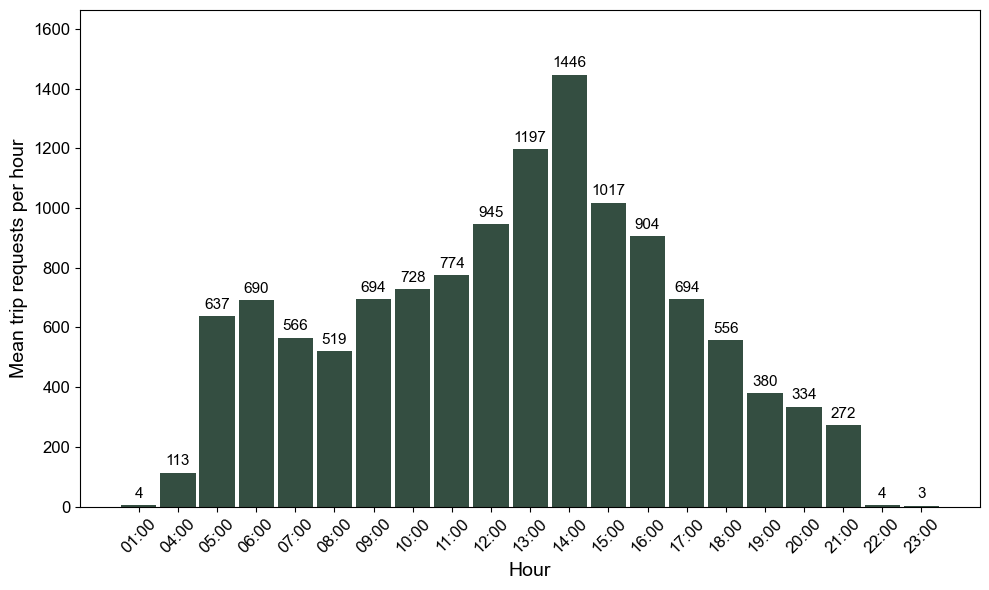

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_demand(df_requests, title_label, color_hex):
    """
    Calculates and plots the mean hourly demand for a given trip DataFrame.
    """
    # 1. Count requests for each (Day, Hour) pair
    demand_by_day_hour = (
        df_requests.groupby(["Day", "Hour"])
        .size()
        .reset_index(name="Requests")
    )

    # 2. Compute mean requests per hour across days
    mean_hourly_demand = (
        demand_by_day_hour.groupby("Hour")["Requests"]
        .mean()
        .reset_index()
    )

    hours = mean_hourly_demand["Hour"].tolist()
    demand_vals = mean_hourly_demand["Requests"].tolist()

    # Format x-axis labels as HH:00
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6)) # Explicit size for consistency
    plt.ylim(0, max(demand_vals)*1.15 if demand_vals else 1)  # Add some headroom
    
    # Use the passed color
    plt.bar(hour_labels, demand_vals, color=color_hex, alpha=1.0, width=0.9)

    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean trip requests per hour", fontsize=14)
    #plt.title(f"Demand Profile: {title_label}", fontsize=font_size+2)

    # Threshold for determining if bar is "too low"
    threshold = 0.10 * max(demand_vals) if demand_vals else 0

    # Label values on bars
    for h, v in zip(hour_labels, demand_vals):
        # Place label ABOVE the bar
        plt.text(h, v + threshold * 0.1,
                 f"{int(v)}",
                 ha='center', va='bottom',
                 color='black', fontsize=11)

    plt.yticks(fontsize=12)
    plt.xticks(rotation=45, fontsize=12)
    #plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Optimize layout FIRST
    plt.tight_layout()
    
    # Save with unique name based on label
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.savefig(
        f"mean_trip_requests_{safe_label}_FINAL.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )

    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (UPDATED FOR ALPHAS)
# ---------------------------

# Define styling variables if not already in context
if 'font_size' not in locals(): font_size = 14
if 'value_size' not in locals(): value_size = 9
bar_color = colors[2][1]  

print(f"Generating demand plots for {len(alpha_results)} Alpha scenarios...")
print(f"Selection Mode: {selection_mode}")

# Loop through the Alpha Results dictionary
for alpha_val, data_dict in alpha_results.items():
    
    # 1. Extract the Trip Requests dataframe for this Alpha
    current_trips_df = data_dict["trip_requests"]
    
    # 2. Create a label (e.g., "Alpha 0.25 (Average)")
    # Note: If selection_mode is an integer, it will say "Alpha 0.25 (Seed 1)"
    plot_label = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Generate Plot
    print(f"   -> Plotting {plot_label}...")
    plot_hourly_demand(
        df_requests=current_trips_df, 
        title_label=plot_label, 
        color_hex=bar_color
    )

## 2.2 Demand across all hours

Generating Full Timeline plots for 1 Alpha scenarios...
Selection Mode: average
DEBUG: Found seeds for alpha 0.250: [1, 2, 3, 4]
   -> Plotting Alpha 0.25 (average) (Normalized by 4 seeds)...


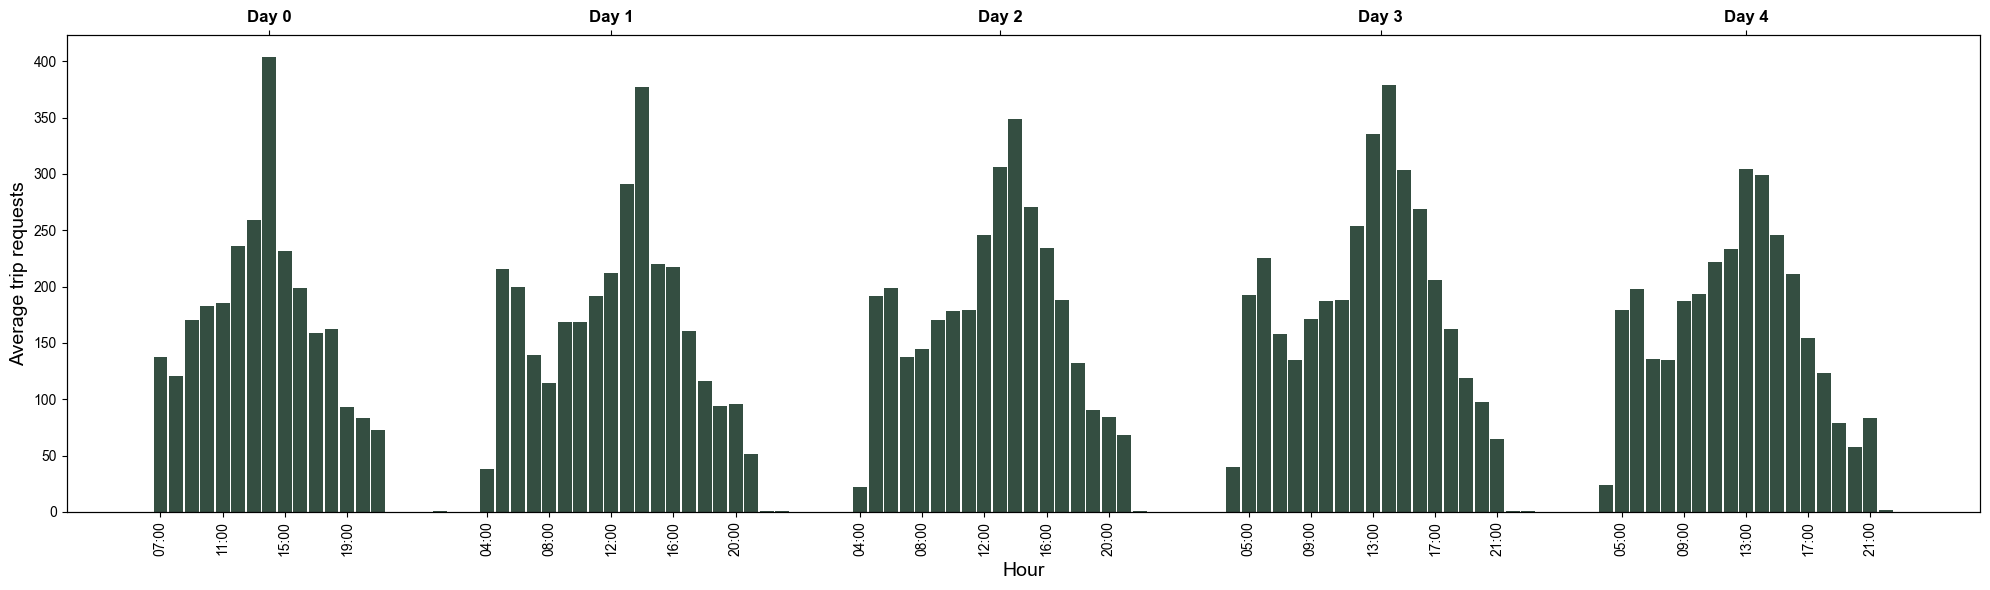

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_full_timeline(df_requests, title_label, scale_factor=1):
    """
    Plots the timeline of requests across all days.
    Applies the global CAP_AT_DAY_4 filter before plotting.
    """
    # 1. APPLY CAP
    # trip_requests_df has 'Day' and 'Hour' columns, so apply_time_cap works natively.
    df_filtered = apply_time_cap(df_requests).copy()
    
    if df_filtered.empty:
        print(f"Warning: No data for {title_label} after filtering.")
        return

    # 2. Count trip requests for each (Day, Hour) pair
    demand_by_day_hour = (
        df_filtered.groupby(["Day", "Hour"])
        .size()
        .reset_index(name="Requests")
    )

    # Normalize if this is an aggregate of multiple seeds
    if scale_factor > 1:
        demand_by_day_hour["Requests"] = demand_by_day_hour["Requests"] / scale_factor

    # Ensure sorting
    demand_by_day_hour = demand_by_day_hour.sort_values(["Day", "Hour"])

    # 3. Prepare flattened index for plotting
    # Create a unique index for each Day-Hour combination
    demand_by_day_hour["DayHourIndex"] = (
        demand_by_day_hour["Day"] * 24 + demand_by_day_hour["Hour"]
    )

    x = demand_by_day_hour["DayHourIndex"]
    y = demand_by_day_hour["Requests"]

    # Bottom x-axis label = hour (formatted)
    hour_labels = [f"{int(h):02d}:00" for h in demand_by_day_hour["Hour"]]

    # Top x-axis labels = day
    day_centers = []
    day_labels = []
    for d in demand_by_day_hour["Day"].unique():
        day_data = demand_by_day_hour[demand_by_day_hour["Day"] == d]
        center = (day_data["DayHourIndex"].min() + day_data["DayHourIndex"].max()) / 2
        day_centers.append(center)
        day_labels.append(f"Day {int(d)}")

    # 4. Plot
    fig, ax1 = plt.subplots(figsize=(20, 6))

    bar_color = colors[2][1]   # Default Orange/Red

    ax1.bar(x, y, width=0.9, color=bar_color)

    ylabel_text = "Average trip requests" if scale_factor > 1 else "Trip requests"
    ax1.set_ylabel(ylabel_text, fontsize=14)
    ax1.set_xlabel("Hour", fontsize=14)

    # Bottom axis -> hours
    # Show every 4th hour if capped, or every 6th if full week to avoid crowding
    step = 4 if CAP_AT_DAY_4 else 6
    
    # Ensure step isn't larger than available data
    step = min(step, len(x)) if len(x) > 0 else 1
    
    ax1.set_xticks(list(x)[::step]) 
    ax1.set_xticklabels([hour_labels[i] for i in range(0, len(hour_labels), step)], 
                        rotation=90, fontsize=10)

    # 5. Add top axis -> days
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(day_centers)
    ax2.set_xticklabels(day_labels, fontsize=12, fontweight="bold")
    #ax2.set_xlabel("Day", fontsize=14)

    # 6. Styling & Saving
    #ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    cap_text = "(Capped Day 4)" if CAP_AT_DAY_4 else "(Full Week)"
    # Title includes Alpha implicitly via title_label passed from loop
    #plt.title(f"Trip Timeline: {title_label} {cap_text}", fontsize=16, pad=20)
    
    safe_name = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    # OPTIMIZE LAYOUT
    plt.tight_layout()
    
    # SAVE WITH NO WHITESPACE
    plt.savefig(
        f"full_timeline_requests_{safe_name}_capped_{CAP_AT_DAY_4}.svg",
        bbox_inches='tight',
        pad_inches=0.02
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (UPDATED FOR ALPHAS)
# ---------------------------

print(f"Generating Full Timeline plots for {len(alpha_results)} Alpha scenarios...")
print(f"Selection Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Prepare Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 2. Determine Scale Factor (for Averaging)
    # We need to know how many seeds were used for THIS specific alpha to normalize correctly
    alpha_str = f"{alpha_val:.3f}"
    seeds_used = get_available_seeds(alpha_str) # Helper from previous cell
    
    if selection_mode == "average":
        scale = len(seeds_used)
        print(f"   -> Plotting {label_text} (Normalized by {scale} seeds)...")
    else:
        scale = 1
        print(f"   -> Plotting {label_text} (Single Seed)...")

    # 3. Plot
    plot_full_timeline(
        df_requests=data_dict["trip_requests"],
        title_label=label_text,
        scale_factor=scale
    )


# 3 Trip requests and fleet aspects

## 3.1 Average fleet criticality

### 3.1.0 Line plot during the day (broad search)

In [ ]:
'''
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ---------------------------
# 0. DEFINE CUSTOM COLORS
# ---------------------------
colors = [
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#C4BEBE"),
    ("Deep Teal", "#1F7A8C"),      # strong contrast vs red/yellow  
    ("Burnt Orange", "#E36414"),  # highly visible and distinct  
    ("Plum Purple", "#6A1E55"),   # contrasts well with blues and greens  
    ("Olive Green", "#7A8F2D")   # readable and distinct from Spruce/Sage  
]

# ---------------------------
# 1. HELPER FUNCTION
# ---------------------------
def process_crit_data(df, window=3):
    """
    Cleans the dataframe, trims start time, and calculates Moving Average.
    """
    c = df[["Day", "Hour", "Avg Bike Criticality"]].copy()
    
    # Fix incorrect hour value "24" -> Hour 0
    mask_24 = c["Hour"] == 24
    c.loc[mask_24, "Hour"] = 0
    
    # Sort cleanly
    c = c.sort_values(["Day", "Hour"]).reset_index(drop=True)

    # --- FILTER START TIME (Start at 07:00 on the first day) ---
    min_day = c["Day"].min()
    mask_start = (c["Day"] > min_day) | ((c["Day"] == min_day) & (c["Hour"] >= 0))
    c = c[mask_start].reset_index(drop=True)
    
    # Moving Average
    c["MA"] = c["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()
    c["hour_label"] = c["Hour"].astype(str).str.zfill(2) + ":00"
    
    return c

# ---------------------------
# 2. DATA PREPARATION
# ---------------------------
window_size = 3
plot_datasets = [] 

print(f"Preparing Criticality Plot with Trend Line...")

# Apply time cap before processing
for i, (alpha_val, data_dict) in enumerate(alpha_results.items()):
    raw_df = apply_time_cap(data_dict["hourly"])
    processed_df = process_crit_data(raw_df, window=window_size)
    
    # CYCLE THROUGH CUSTOM COLORS
    color_tuple = colors[i % len(colors)] 
    hex_color = color_tuple[1]
    
    label_text = rf"$\alpha = {alpha_val}$"
    plot_datasets.append((label_text, processed_df, hex_color))

# ---------------------------
# IDENTIFY ALPHA 0.2 AND 0.3 DATA
# ---------------------------
df_alpha_02 = None
df_alpha_03 = None

for label, df, color in plot_datasets:
    if label == rf"$\alpha = 0.2$":
        df_alpha_02 = df
    elif label == rf"$\alpha = 0.3$":
        df_alpha_03 = df

if df_alpha_02 is None or df_alpha_03 is None:
    raise ValueError("Alpha 0.2 or Alpha 0.3 not found in plot_datasets.")


# ---------------------------
# 3. IDENTIFY X-AXIS & BOUNDARIES
# ---------------------------
if not plot_datasets:
    raise ValueError("No data found to plot.")

ref_df = plot_datasets[0][1]
x_ref = ref_df.index

# Find day boundaries
day_change_idx = ref_df.index[ref_df["Day"].ne(ref_df["Day"].shift())].tolist()
boundary_positions = [x for x in day_change_idx if x > 0]

day_centers = []
day_labels = []
for day_val in ref_df["Day"].unique():
    # Skip Day 5 label if it's just the single cutoff point
    if CAP_AT_DAY_4 and day_val >= 5:
        continue
        
    idxs = ref_df.index[ref_df["Day"] == day_val]
    if len(idxs) > 0:
        center = (idxs[0] + idxs[-1]) / 2
        day_centers.append(center)
        day_labels.append(f"Day {int(day_val)}")

# ---------------------------
# 4. PLOTTING
# ---------------------------
fig, ax = plt.subplots(figsize=(16, 6))

for label, df, color in plot_datasets:
    ax.plot(df.index, df["MA"], linewidth=3, color=color, label=label)

# --- 4b. ADD TREND LINE (GROWTH LINE) ---
# We calculate the trend based on the FIRST dataset (usually Alpha 0 or the baseline)
# You can change index [0] to another index if you want the trend of a different Alpha
trend_source_df = plot_datasets[0][1] 

# Create x values (0, 1, 2...) matching the index
x_trend = np.arange(len(trend_source_df))
y_trend = trend_source_df["MA"].fillna(method='bfill') # Fill NaNs for calculation

# Calculate Linear Regression (Polyfit degree 1)
#slope, intercept = np.polyfit(x_trend, y_trend, 1)

# Generate Y values for the line
#trend_line_y = slope * x_trend + intercept

# Plot the trend line
#ax.plot(x_trend, trend_line_y, color="black", linestyle="--", linewidth=2, 
        #label=f"Trend (Slope: {slope:.4f})", alpha=0.6)
# ----------------------------------------
# ---------------------------
# SHADE AREA BETWEEN ALPHA 0.2 AND 0.3
# ---------------------------
ax.fill_between(
    df_alpha_02.index,
    df_alpha_02["MA"],
    df_alpha_03["MA"],
    color="#526ECA3D",   # Blue Accent (or any contrast color)
    alpha=0.15,
)


# Vertical lines (Day boundaries)
for pos in boundary_positions:
    ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.2)

# ---------------------------
# AXIS SETTINGS
# ---------------------------

# 1. X-Axis Limits (No Gap)
ax.set_xlim(x_ref[0], x_ref[-1])

# 2. Y-Axis Limits
ax.set_ylim(0.3, 0.7)

# 3. Granular Ticks
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))

# Grid settings
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.4, color='gray')
#ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')

# FONT SIZES
ax.set_ylabel("Average fleet criticality", fontsize=16)
ax.set_xlabel("Hour", fontsize=16)

# 4. X-Axis (Bottom) - Show hour labels
denom = 15 if CAP_AT_DAY_4 else 25
step = max(1, len(ref_df) // denom)
ax.set_xticks(list(x_ref)[::step])
ax.set_xticklabels(ref_df["hour_label"].iloc[::step], 
                   rotation=45, ha="right", fontsize=12)

# Tick label size
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', which='both', bottom=True, top=False)

# ---------------------------
# 5. SECONDARY AXIS (Top) - Show day labels
# ---------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()) 
ax2.set_xticks(day_centers)
ax2.set_xticklabels(day_labels, fontsize=12, fontweight='bold')
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")
ax2.tick_params(axis='x', which='both', bottom=False, top=False)

# Legend positioning
ax.legend(loc='upper left', fontsize=14)

# 6. SAVE
plt.tight_layout()

filename = f"average_fleet_criticality_{alpha_val}_trendline_{CAP_AT_DAY_4}.svg"
plt.savefig(
    filename, 
    bbox_inches='tight', 
    pad_inches=0.02
)

plt.show()
'''

'\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport matplotlib.ticker as ticker\nimport numpy as np\n\n# ---------------------------\n# 0. DEFINE CUSTOM COLORS\n# ---------------------------\ncolors = [\n    ("Dark Spruce", "#344E41"),\n    ("Warm Red", "#D1495B"),\n    ("Ochre Gold", "#EDAE49"),\n    ("Blue Accent", "#526ECA"),  \n    ("Mist Grey", "#C4BEBE"),\n    ("Deep Teal", "#1F7A8C"),      # strong contrast vs red/yellow  \n    ("Burnt Orange", "#E36414"),  # highly visible and distinct  \n    ("Plum Purple", "#6A1E55"),   # contrasts well with blues and greens  \n    ("Olive Green", "#7A8F2D")   # readable and distinct from Spruce/Sage  \n]\n\n# ---------------------------\n# 1. HELPER FUNCTION\n# ---------------------------\ndef process_crit_data(df, window=3):\n    """\n    Cleans the dataframe, trims start time, and calculates Moving Average.\n    """\n    c = df[["Day", "Hour", "Avg Bike Criticality"]].copy()\n\n    # Fix incorrect hour value "24" -> Hour 0\n   

### 3.1.1 Line plot during the day (finetuning)

### 3.1.2 Map showing average criticality of all stations

In [ ]:
# ---------------------------
# HELPER: COLOR FUNCTION
# ---------------------------
def crit_color(c):
    if c >= 0.6:
        return "red"
    elif c >= 0.5:
        return "orange"
    elif c >= 0.4:
        return "yellow"
    else:
        return "green"

# ---------------------------
# EXECUTION LOGIC (Looping through Alphas)
# ---------------------------
print(f"Generating Station Maps for {len(alpha_results)} Alpha scenarios...")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the station hourly data for this Alpha
    # (Note: Use .copy() to avoid SettingWithCopy warnings on the original df)
    station_hourly_activity_df = data_dict["station_hourly"].copy()
    
    print(f"   -> Processing Map for Alpha {alpha_val}...")

    # 2. Extract numeric station id from "S0", "S1", ...
    #    This regex method is robust for mixed formats
    if station_hourly_activity_df["Station ID"].dtype == object:
        station_hourly_activity_df["id"] = (
            station_hourly_activity_df["Station ID"]
            .astype(str)
            .str.extract(r"S(\d+)")
            .astype(int)
        )
    else:
        # If it's already numeric (some datasets), just copy it
        station_hourly_activity_df["id"] = station_hourly_activity_df["Station ID"]

    # 3. Compute per-row share of capacity that is broken
    #    guard against capacity = 0 just in case
    station_hourly_activity_df["broken_share"] = (
        station_hourly_activity_df["Unusable Bikes"] /
        station_hourly_activity_df["Capacity"].replace(0, np.nan)
    )

    # 4. Average maintenance criticality AND avg % broken per station
    crit_per_station = (
        station_hourly_activity_df
        .groupby("id", as_index=False)
        .agg(
            avg_maint_crit=("Avg Maintenance Criticality", "mean"),
            avg_broken_share=("broken_share", "mean")   # this is 0–1
        )
    )

    # 5. Merge with coordinates from stations_df (must already have lat/lon)
    stations_crit = stations_df.merge(crit_per_station, on="id", how="left")
    stations_crit["avg_maint_crit"] = stations_crit["avg_maint_crit"].fillna(0.0)
    stations_crit["avg_broken_share"] = stations_crit["avg_broken_share"].fillna(0.0)

    # 6. Initialize Map
    center_lat = stations_crit["lat"].mean()
    center_lon = stations_crit["lon"].mean()
    
    # Create map with a unique object name
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

    # 7. Add Markers
    for _, row in stations_crit.iterrows():
        c = row["avg_maint_crit"]
        broken_pct = row["avg_broken_share"] * 100  # turn into %

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=6,  # could also scale with broken_pct if you like
            fill=True,
            fill_opacity=0.8,
            color=crit_color(c),
            fill_color=crit_color(c),
            popup=(
                f"Station S{int(row['id'])}<br>"
                f"Alpha: {alpha_val}<br>"
                f"Avg maint. criticality: {c:.3f}<br>"
                f"Avg broken: {broken_pct:.1f}% of capacity"
            ),
        ).add_to(m)

    # 8. Save with Unique Name
    #    Filename includes Alpha and Selection Mode (e.g., "seed_1" or "average")
    mode_label = f"seed_{selection_mode}" if isinstance(selection_mode, int) else selection_mode
    filename = f"station_criticality_map_{mode_label}_Alpha_{alpha_val}.html"
    
    m.save(filename)
    print(f"      Saved: {filename}")

print("\nDone.")

Generating Station Maps for 1 Alpha scenarios...
   -> Processing Map for Alpha 0.25...
      Saved: station_criticality_map_average_Alpha_0.25.html

Done.


## 3.2 Service rate computation

In [19]:
# ---------------------------
# 1. METRIC CALCULATION FUNCTION
# ---------------------------
def calculate_service_metrics(df_trips, df_hourly, scale_factor=1):
    """
    Calculates system-wide service metrics.
    
    Args:
        df_trips: DataFrame containing trip logs.
        df_hourly: DataFrame containing hourly stats (must contain 'Long Congestions').
        scale_factor: int/float. Used to normalize trip counts if df_trips contains 
                      stacked data from multiple seeds. 
                      (e.g., if Average mode over 5 seeds, scale_factor=5).
    """
    # 1. Total Requests (Normalized)
    raw_requests = len(df_trips)
    total_requests = raw_requests / scale_factor
    
    # 2. Successful Trips (Normalized)
    # A trip is successful if "Failure Reason" is NaN
    raw_successful = df_trips["Failure Reason"].isna().sum()
    total_successful = raw_successful / scale_factor
    
    # 3. Total Long Congestions
    # If df_hourly is already an 'average' dataframe, sum() gives the average weekly total.
    # If df_hourly is a single seed, sum() gives that seed's total.
    total_long_congestions = df_hourly["Long Congestions"].sum()
    
    # 4. Effective Success (Penalized by Congestion)
    # We subtract congestions from successes to account for trips that 'succeeded' 
    # but arrived at a full station (blocked).
    effective_total_successful = max(total_successful - total_long_congestions, 0)
    
    # 5. Service Rate
    service_rate = (effective_total_successful / total_requests) if total_requests > 0 else 0
    
    return {
        "Total Requests": round(total_requests, 1),
        "Successful Trips": round(total_successful, 1),
        "Long Congestions": round(total_long_congestions, 1),
        "Effective Success": round(effective_total_successful, 1),
        "Service Rate": service_rate # Keep as float for formatting later
    }

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"\n{'='*20} SERVICE LEVEL ANALYSIS COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

comparison_list = []

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Determine Scale Factor
    # We need to know how many seeds were used for THIS specific alpha to normalize correctly
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str) # Re-scan to get count
        scale = len(seeds_used)
    else:
        scale = 1 # Single seed mode
        
    # 2. Calculate Metrics
    metrics = calculate_service_metrics(
        df_trips=data_dict["trip_requests"],
        df_hourly=data_dict["hourly"],
        scale_factor=scale
    )
    
    # 3. Add Identity info
    metrics["Alpha"] = alpha_val
    comparison_list.append(metrics)

# ---------------------------
# 3. DISPLAY RESULTS
# ---------------------------
if comparison_list:
    # Create DataFrame
    results_df = pd.DataFrame(comparison_list)
    
    # Reorder columns to put Alpha first
    cols = ["Alpha", "Total Requests", "Successful Trips", "Long Congestions", "Effective Success", "Service Rate"]
    results_df = results_df[cols]
    
    # Format Service Rate as percentage string for display
    # (We operate on a copy for display so we don't break the float values if needed later)
    display_df = results_df.copy()
    display_df["Service Rate"] = display_df["Service Rate"].apply(lambda x: f"{x:.2%}")
    
    print("\n")
    print(display_df.to_string(index=False))
    
    # Optional: Quick textual summary of the best Alpha
    best_alpha_idx = results_df["Service Rate"].idxmax()
    best_alpha = results_df.loc[best_alpha_idx, "Alpha"]
    best_rate = results_df.loc[best_alpha_idx, "Service Rate"]
    
    print(f"\nBest Performing Policy: Alpha {best_alpha} (Service Rate: {best_rate:.2%})")

else:
    print("No data available for analysis.")

print("=" * 60)


==================== SERVICE LEVEL ANALYSIS COMPARISON ====================
Aggregation Mode: average
DEBUG: Found seeds for alpha 0.000: [1, 2, 3, 4]


 Alpha  Total Requests  Successful Trips  Long Congestions  Effective Success Service Rate
   0.0         15742.5           14826.2             452.0            14374.2       91.31%

Best Performing Policy: Alpha 0.0 (Service Rate: 91.31%)


# 4 Failed events

Generating Event plots for 1 Alpha scenarios...
Mode: average
   -> Plotting Alpha 0.25 (average)...


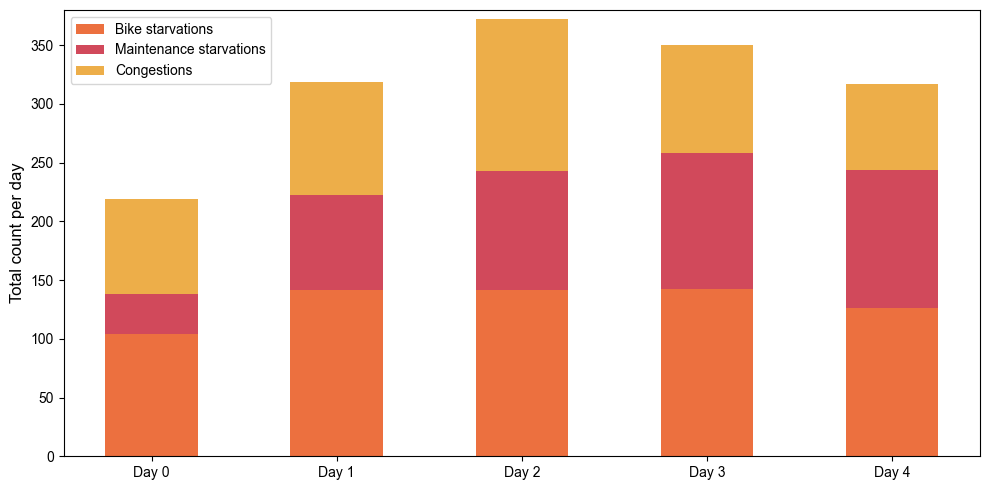

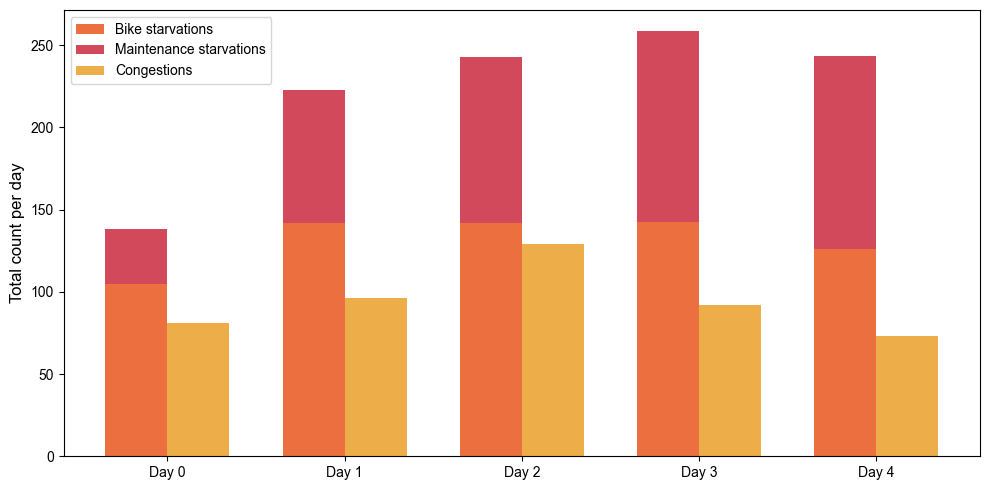

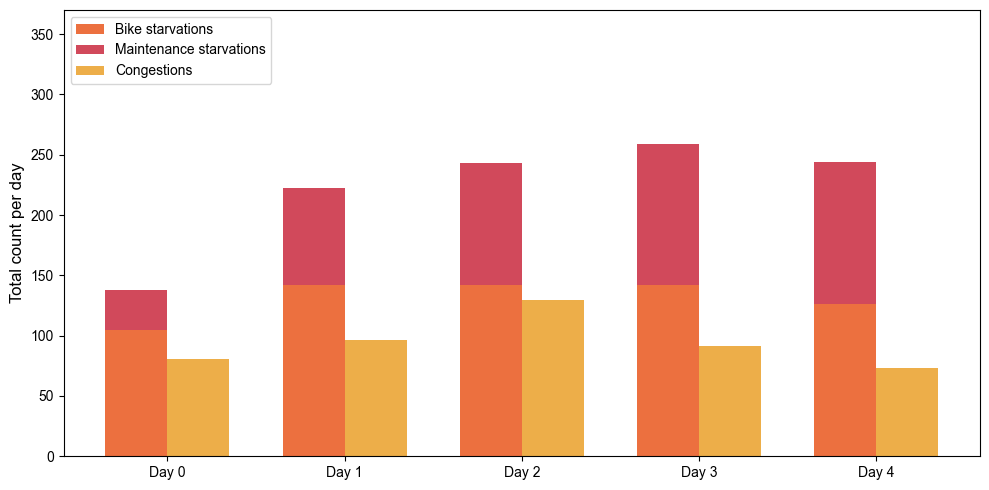

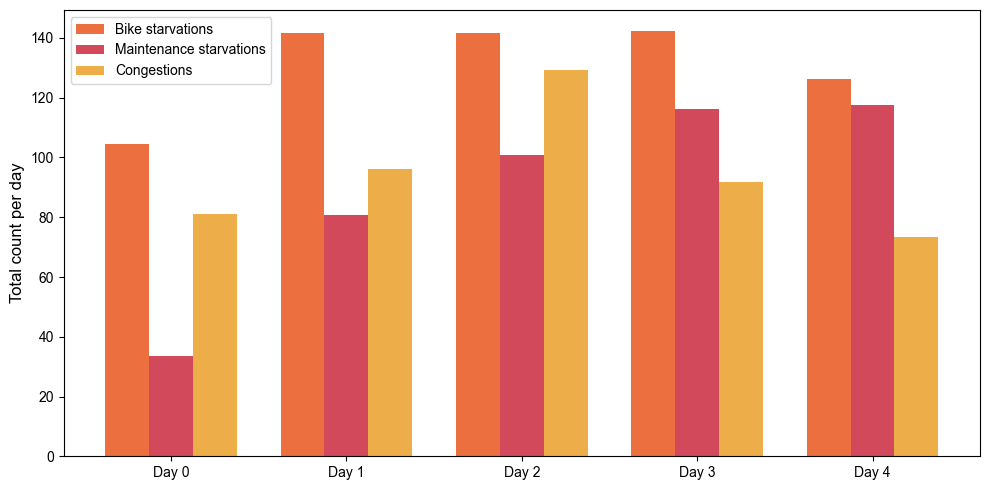

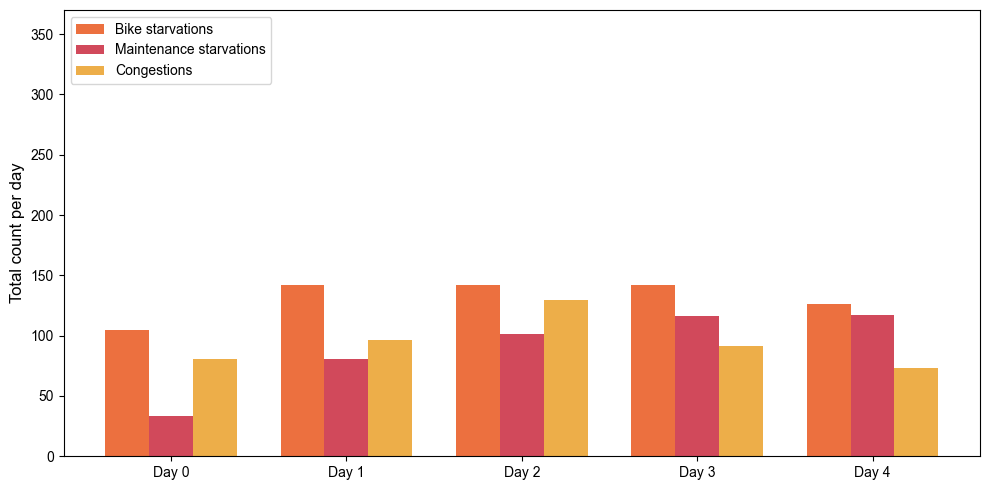

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# 1. SETUP COLORS (Full Palette)
# ---------------------------
colors = [
    ("Pale Fern", "#D9E5D6"),   # 0
    ("Sage Green", "#84A579"),  # 1
    ("Dark Spruce", "#344E41"), # 2 (Green)
    ("Warm Red", "#D1495B"),    # 3 (Red)
    ("Ochre Gold", "#EDAE49"),  # 4 (Gold)
    ("Blue Accent", "#526ECA"), # 5 (Blue)
    ("Mist Grey", "#E6E6E6"),   # 6
]

# ---------------------------
# 2. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_daily_events(df_hourly, title_label):
    """
    Aggregates hourly data by Day and plots TWO bar charts:
    1. Fully stacked: All three categories in one bar
    2. Grouped: Starvations stacked, Congestions separate
    """
    # 1. APPLY CAP AND FILTER
    df_filtered = apply_time_cap(df_hourly).copy()
    df_filtered = df_filtered[df_filtered["Day"] < 5]
    
    if df_filtered.empty:
        print(f"Warning: No data for {title_label} after filtering.")
        return

    # 2. GROUP BY DAY
    daily = (
        df_filtered.groupby("Day")
        .agg({
            "Bike Starvations": "sum",
            "Maintenance Starvations": "sum",
            "Long Congestions": "sum",
        })
        .reset_index()
    )

    # 3. PREPARE DATA
    days = daily["Day"].values
    bike_starv = daily["Bike Starvations"].values
    maint_starv = daily["Maintenance Starvations"].values
    congestions = daily["Long Congestions"].values 
    x = np.arange(len(days))
    
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")

    # 4A-SCALED. PLOT 1 SCALED: FULLY STACKED
    plt.figure(figsize=(10, 5))
    plt.bar(x, bike_starv, width=0.5, 
            label="Bike starvations", color=activity_colors["Bike_starvations"]) 
    plt.bar(x, maint_starv, width=0.5, bottom=bike_starv,
            label="Maintenance starvations", color=activity_colors["Maint_starvations"]) 
    plt.bar(x, congestions, width=0.5, bottom=bike_starv + maint_starv,
            label="Congestions", color=activity_colors["Congestions"]) 
    
    plt.ylim(0, 380)
    plt.ylabel("Total count per day", fontsize=12)
    plt.xticks(x, [f"Day {int(d)}" for d in days])
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(f"daily_failed_events_stacked_{safe_label}_FINAL_SCALED.svg",
                bbox_inches='tight', pad_inches=0.02)
    plt.show()

    # 4B. PLOT 2: GROUPED (STARVATIONS VS CONGESTIONS)
    plt.figure(figsize=(10, 5))
    width = 0.35
    plt.bar(x - width/2, bike_starv, width=width, 
            label="Bike starvations", color=activity_colors["Bike_starvations"]) 
    plt.bar(x - width/2, maint_starv, width=width, bottom=bike_starv,
            label="Maintenance starvations", color=activity_colors["Maint_starvations"]) 
    plt.bar(x + width/2, congestions, width=width,
            label="Congestions", color=activity_colors["Congestions"]) 
    
    plt.ylabel("Total count per day", fontsize=12)
    plt.xticks(x, [f"Day {int(d)}" for d in days])
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(f"daily_failed_events_grouped_{safe_label}_FINAL.svg",
                bbox_inches='tight', pad_inches=0.02)
    plt.show()

    # 4B-SCALED. PLOT 2 SCALED: GROUPED (STARVATIONS VS CONGESTIONS)
    plt.figure(figsize=(10, 5))
    width = 0.35
    plt.bar(x - width/2, bike_starv, width=width, 
            label="Bike starvations", color=activity_colors["Bike_starvations"]) 
    plt.bar(x - width/2, maint_starv, width=width, bottom=bike_starv,
            label="Maintenance starvations", color=activity_colors["Maint_starvations"]) 
    plt.bar(x + width/2, congestions, width=width,
            label="Congestions", color=activity_colors["Congestions"]) 
    
    plt.ylim(0, 370)
    plt.ylabel("Total count per day", fontsize=12)
    plt.xticks(x, [f"Day {int(d)}" for d in days])
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(f"daily_failed_events_grouped_{safe_label}_FINAL_SCALED.svg",
                bbox_inches='tight', pad_inches=0.02)
    plt.show()

    # 4C. PLOT 3: FULLY UNGROUPED (All three categories separate)
    plt.figure(figsize=(10, 5))
    width = 0.25
    plt.bar(x - width, bike_starv, width=width, 
            label="Bike starvations", color=activity_colors["Bike_starvations"]) 
    plt.bar(x, maint_starv, width=width,
            label="Maintenance starvations", color=activity_colors["Maint_starvations"]) 
    plt.bar(x + width, congestions, width=width,
            label="Congestions", color=activity_colors["Congestions"]) 
    
    plt.ylabel("Total count per day", fontsize=12)
    plt.xticks(x, [f"Day {int(d)}" for d in days])
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(f"daily_failed_events_ungrouped_{safe_label}_FINAL.svg",
                bbox_inches='tight', pad_inches=0.02)
    plt.show()

    # 4C-SCALED. PLOT 3 SCALED: FULLY UNGROUPED (All three categories separate)
    plt.figure(figsize=(10, 5))
    width = 0.25
    plt.bar(x - width, bike_starv, width=width, 
            label="Bike starvations", color=activity_colors["Bike_starvations"]) 
    plt.bar(x, maint_starv, width=width,
            label="Maintenance starvations", color=activity_colors["Maint_starvations"]) 
    plt.bar(x + width, congestions, width=width,
            label="Congestions", color=activity_colors["Congestions"]) 
    
    plt.ylim(0, 370)
    plt.ylabel("Total count per day", fontsize=12)
    plt.xticks(x, [f"Day {int(d)}" for d in days])
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(f"daily_failed_events_ungrouped_{safe_label}_FINAL_SCALED.svg",
                bbox_inches='tight', pad_inches=0.02)
    plt.show()

# ---------------------------
# 3. EXECUTION LOGIC
# ---------------------------
print(f"Generating Event plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    current_hourly_df = data_dict["hourly"]
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    print(f"   -> Plotting {label_text}...")
    plot_daily_events(
        df_hourly=current_hourly_df,
        title_label=label_text
    )

Generating Event plots for 1 Alpha scenarios...
Mode: average
   -> Plotting Alpha 0.25 (average)...


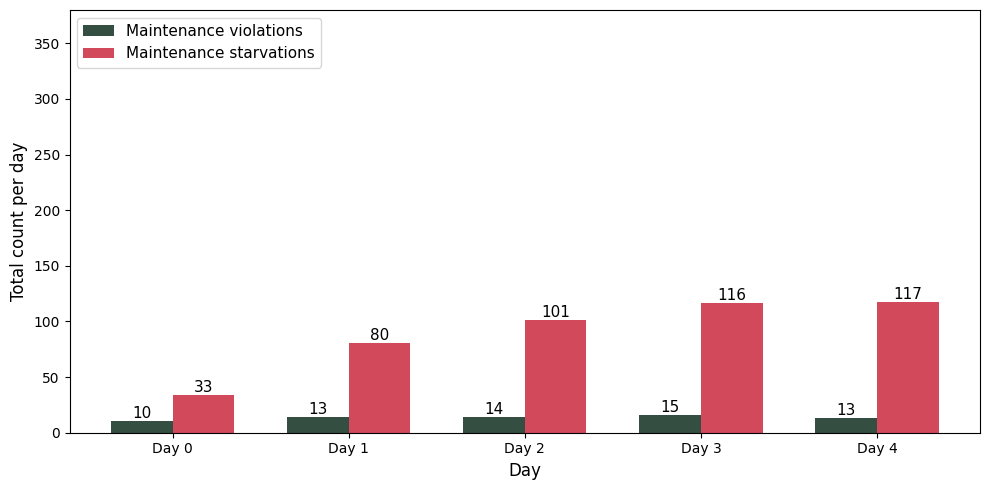

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# 1. SETUP COLORS (Full Palette)
# ---------------------------
colors = [
    ("Pale Fern", "#D9E5D6"),   # 0
    ("Sage Green", "#84A579"),  # 1
    ("Dark Spruce", "#344E41"), # 2 (Green)
    ("Warm Red", "#D1495B"),    # 3 (Red)
    ("Ochre Gold", "#EDAE49"),  # 4 (Gold)
    ("Blue Accent", "#526ECA"), # 5 (Blue)
    ("Mist Grey", "#E6E6E6"),   # 6
]

# ---------------------------
# 2. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_daily_events(df_hourly, title_label):
    """
    Aggregates hourly data by Day and plots grouped bar chart:
    Maintenance violations and Maintenance starvations side-by-side
    """
    # 1. APPLY CAP AND FILTER
    df_filtered = apply_time_cap(df_hourly).copy()
    df_filtered = df_filtered[df_filtered["Day"] < 5]
    
    if df_filtered.empty:
        print(f"Warning: No data for {title_label} after filtering.")
        return

    # 2. GROUP BY DAY
    daily = (
        df_filtered.groupby("Day")
        .agg({
            "Maintenance Violations": "sum",
            "Maintenance Starvations": "sum",
        })
        .reset_index()
    )

    # 3. PREPARE DATA
    days = daily["Day"].values
    maint_violations = daily["Maintenance Violations"].values
    maint_starv = daily["Maintenance Starvations"].values
    
    # 4. GROUPED BAR CHART
    x = np.arange(len(days))
    width = 0.35  # Width of bars
    
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")

    plt.figure(figsize=(10, 5))
    
    # Plot bars side by side
    plt.bar(x - width/2, maint_violations, width, 
            label="Maintenance violations", color=colors[2][1]) 
    plt.bar(x + width/2, maint_starv, width,
            label="Maintenance starvations", color=activity_colors["Maint_starvations"]) 
    
    # Add value labels on bars
    for i, v in enumerate(maint_violations):
        if v > 0:
            plt.text(i - width/2, v, str(int(v)), ha='center', va='bottom', fontsize=11)
    
    for i, v in enumerate(maint_starv):
        if v > 0:
            plt.text(i + width/2, v, str(int(v)), ha='center', va='bottom', fontsize=11)
    
    plt.ylim(0, 380)
    plt.ylabel("Total count per day", fontsize=12)
    plt.xlabel("Day", fontsize=12)
    plt.xticks(x, [f"Day {int(d)}" for d in days])
    plt.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.savefig(f"daily_failed_events_grouped_{safe_label}_FINAL.svg",
                bbox_inches='tight', pad_inches=0.02)
    plt.show()

# ---------------------------
# 3. EXECUTION LOGIC
# ---------------------------
print(f"Generating Event plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    current_hourly_df = data_dict["hourly"]
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    print(f"   -> Plotting {label_text}...")
    plot_daily_events(
        df_hourly=current_hourly_df,
        title_label=label_text
    )

## 4.1 Bike starvation

### 4.1.1 Plot for mean over all hours of simulation horizon

Generating Starvation plots for 1 Alpha scenarios...
Mode: average
   -> Plotting Alpha 0.25 (average)...


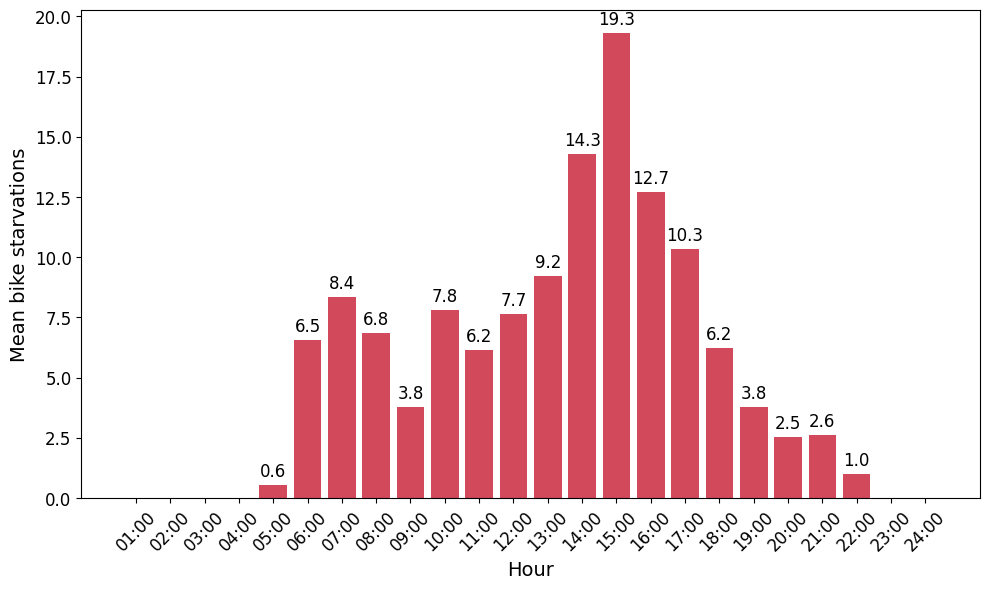

In [11]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_starvations(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly bike starvations.
    """
    # 1. Sum starvations for each (Day, Hour) pair within this dataset
    # (If df_hourly is averaged, this is the average sum per day)
    starv_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Bike Starvations"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean starvations per hour across the simulated days
    mean_hourly_starv = (
        starv_by_day_hour.groupby("Hour")["Bike Starvations"]
        .mean()
        .reset_index()
    )

    # Extract hours and values
    hours = mean_hourly_starv["Hour"].tolist()
    starv_vals = mean_hourly_starv["Bike Starvations"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, starv_vals, color=color_hex, alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean bike starvations", fontsize=14)
    #plt.title(f"Starvation Profile: {title_label}", fontsize=16)

    # Handle case where max is 0 (perfect run)
    max_val = max(starv_vals) if starv_vals else 0
    threshold = 0.10 * max_val if max_val > 0 else 0

    # Label values on bars
    for h, v in zip(hour_labels, starv_vals):
        if v > 0.05: # Only label if value is significant
            plt.text(h, v + threshold * 0.1,
                     f"{v:.1f}",
                     ha='center', va='bottom',
                     color='black', fontsize=12)

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    
    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"mean_bike_starvations_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

# Define styling
bar_color = colors[3][1]   # Default Red/Orange for Starvations

print(f"Generating Starvation plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_hourly_starvations(
        df_hourly=current_hourly_df,
        title_label=label_text,
        color_hex=bar_color
    )

## 4.2 Congestion

### 4.2.1 Plot mean over all hours of simulation horizon (24h agg)

Generating Congestion plots for 1 Alpha scenarios...
Mode: average
   -> Plotting Alpha 0.25 (average)...


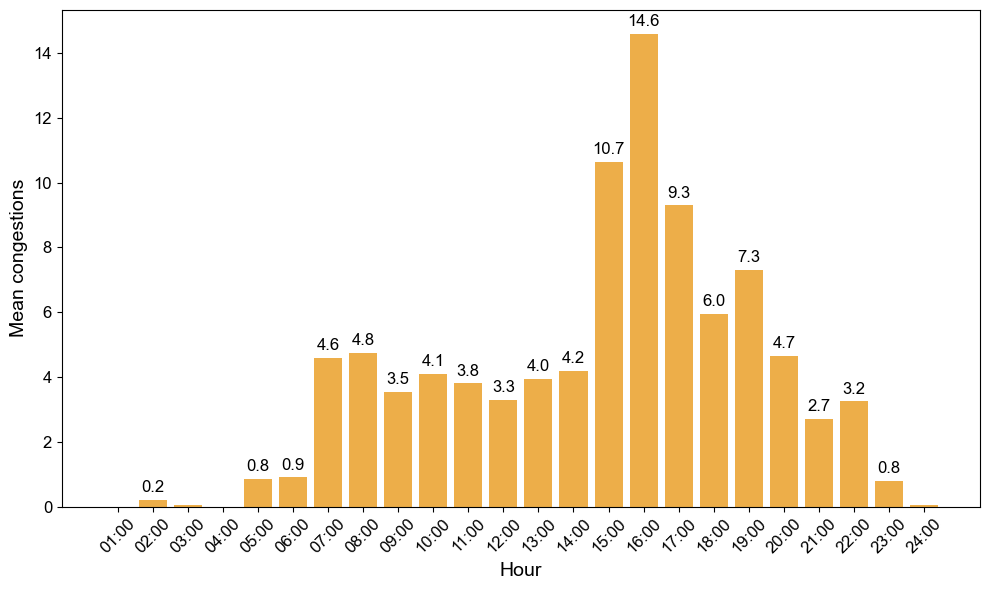

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_congestions(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly long congestions.
    """
    # 1. Sum congestions for each (Day, Hour) pair
    cong_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Long Congestions"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean congestions per hour across days
    mean_hourly_cong = (
        cong_by_day_hour.groupby("Hour")["Long Congestions"]
        .mean()
        .reset_index()
    )

    # Extract hours and mean values
    hours = mean_hourly_cong["Hour"].tolist()
    cong_vals = mean_hourly_cong["Long Congestions"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, cong_vals, color=color_hex, alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean congestions", fontsize=14)
    #plt.title(f"Congestion Profile: {title_label}", fontsize=16, pad=15)

    # Handle scale for label placement
    max_val = max(cong_vals) if cong_vals else 0
    threshold = 0.10 * max_val if max_val > 0 else 0

    # Label values on bars
    for h, v in zip(hour_labels, cong_vals):
        if v > 0.05: # Only label if value is non-zero/significant
            plt.text(h, v + threshold * 0.1,
                     f"{v:.1f}",
                     ha='center', va='bottom',
                     color='black', fontsize=12)

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    #plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"mean_long_congestions_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

# Define styling
bar_color = colors[4][1]   # Default Green/Teal for Congestions

print(f"Generating Congestion plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_hourly_congestions(
        df_hourly=current_hourly_df,
        title_label=label_text,
        color_hex=bar_color
    )

# 4.3 Maintenance violations

Generating Maintenance Violation plots for 1 Alpha scenarios...
Mode: average
   -> Plotting Alpha 0.25 (average)...


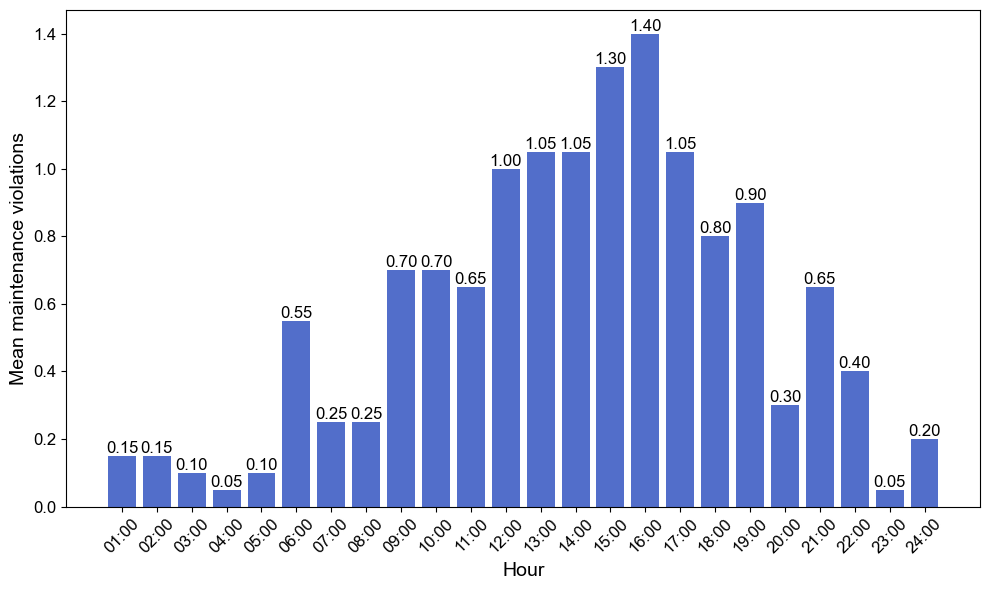

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_maintenance_violations(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly maintenance violations.
    """
    # 1. Sum maintenance violations for each (Day, Hour) pair
    maintV_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Maintenance Violations"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean violations per hour across days
    mean_hourly_maintV = (
        maintV_by_day_hour.groupby("Hour")["Maintenance Violations"]
        .mean()
        .reset_index()
    )

    # Extract hours and values
    hours = mean_hourly_maintV["Hour"].tolist()
    maintV_vals = mean_hourly_maintV["Maintenance Violations"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, maintV_vals, color=color_hex, alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean maintenance violations", fontsize=14)
    #plt.title(f"Hourly Maintenance Violations: {title_label}", fontsize=16, pad=15)

    # Value labels OUTSIDE bars
    for h, v in zip(hour_labels, maintV_vals):
        if v > 0.0:
            plt.text(
                h, 
                v,                # Y-position: Top of the bar
                f"{v:.2f}",       # Keep 2 decimals for small violation counts
                ha='center', 
                va='bottom',      # Align bottom of text to value
                color='black', 
                fontsize=12,
            )

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    #plt.grid(axis='y', linestyle='--', alpha=0.3) 

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"mean_maintenance_violations_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

# Define styling
bar_color = colors[5][1]   # Blue (as requested)

print(f"Generating Maintenance Violation plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_hourly_maintenance_violations(
        df_hourly=current_hourly_df,
        title_label=label_text,
        color_hex=bar_color
    )

## 4.4 Maintenance starvations

### 4.4.1 Accumulated for different parts of day

In [ ]:
# ---------------------------
# 1. CONFIGURATION
# ---------------------------
# Define time blocks
# Note: Ranges in Python lists include the listed numbers.
time_blocks = {
    "Morning (07-10)": [7, 8, 9, 10],
    "Early Mid (11-12)": [11, 12],
    "Late Mid (13-14)": [13, 14],
    "Afternoon (15-18)": [15, 16, 17, 18],
    "Evening (19-22)": [19, 20, 21, 22]
}

# ---------------------------
# 2. ANALYSIS FUNCTION
# ---------------------------
def analyze_time_blocks(df_hourly):
    """
    Aggregates 'Maintenance Starvations' by specific time blocks.
    Returns a dictionary of results.
    """
    # Sum starvations by hour (across all days in the week)
    # If df_hourly is an average df, this gives Average Weekly Starvations per hour
    maint_by_hour = (
        df_hourly
        .groupby("Hour")["Maintenance Starvations"]
        .sum()
    )
    
    results = {}
    
    # Calculate sum for each block
    for block_name, hours in time_blocks.items():
        # intersection() ensures we don't crash if an hour is missing from data
        valid_hours = list(set(hours).intersection(maint_by_hour.index))
        val = maint_by_hour.loc[valid_hours].sum()
        results[block_name] = round(val, 2)
        
    # Calculate Ratio
    morning_val = results["Morning (07-10)"]
    afternoon_val = results["Afternoon (15-18)"]
    
    if afternoon_val > 0:
        ratio = round(morning_val / afternoon_val, 2)
    else:
        ratio = np.nan
        
    results["Ratio (Morn/Aft)"] = ratio
    return results

# ---------------------------
# 3. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"\n{'='*20} TIME OF DAY ANALYSIS COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

comparison_list = []

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Analyze for this Alpha
    stats = analyze_time_blocks(data_dict["hourly"])
    
    # 2. Add Identity info
    stats["Alpha"] = alpha_val
    comparison_list.append(stats)

# ---------------------------
# 4. DISPLAY RESULTS
# ---------------------------
if comparison_list:
    # Create DataFrame
    results_df = pd.DataFrame(comparison_list)
    
    # Reorder cols to put Alpha first
    cols = ["Alpha"] + list(time_blocks.keys()) + ["Ratio (Morn/Aft)"]
    results_df = results_df[cols]
    
    print("\n")
    print(results_df.to_string(index=False))
    
    # Optional: Highlight trends
    print("\n--- Insight ---")
    best_morning_alpha = results_df.loc[results_df["Morning (07-10)"].idxmin(), "Alpha"]
    print(f"Lowest Morning Starvations: Alpha {best_morning_alpha}")

else:
    print("No data available for analysis.")

print("=" * 60)


==================== TIME OF DAY ANALYSIS COMPARISON ====================
Aggregation Mode: average


 Alpha  Morning (07-10)  Early Mid (11-12)  Late Mid (13-14)  Afternoon (15-18)  Evening (19-22)  Ratio (Morn/Aft)
  0.25           109.75               54.5             79.75             141.25            34.75              0.78

--- Insight ---
Lowest Morning Starvations: Alpha 0.25


### 4.4.2 Plot for mean over all hours of simulation horizon

Generating Maintenance Starvation plots for 1 Alpha scenarios...
Mode: average
   -> Plotting Alpha 0.25 (average)...


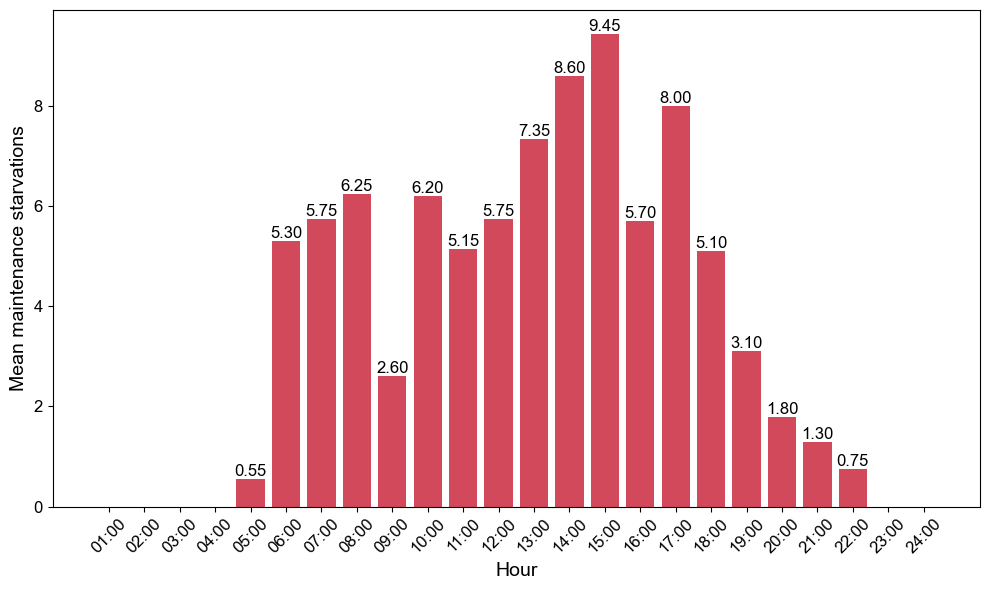

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_maintenance_starvations(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly maintenance starvations.
    """
    # 1. Sum maintenance starvations for each (Day, Hour) pair
    # If df_hourly is averaged, this is the average sum per day
    maint_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Maintenance Starvations"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean starvations per hour across days
    mean_hourly_maint = (
        maint_by_day_hour.groupby("Hour")["Maintenance Starvations"]
        .mean()
        .reset_index()
    )

    # Extract hours and values
    hours = mean_hourly_maint["Hour"].tolist()
    maint_vals = mean_hourly_maint["Maintenance Starvations"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, maint_vals, color=activity_colors["Maint_starvations"], alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean maintenance starvations", fontsize=14)
    #plt.title(f"Maint. Starvation Profile: {title_label}", fontsize=16, pad=15)
    
    # Value labels OUTSIDE bars
    for h, v in zip(hour_labels, maint_vals):
        if v > 0.0: # Check if value is significant
            plt.text(
                h, 
                v,                # Y-position: Top of the bar
                f"{v:.2f}", 
                ha='center', 
                va='bottom',      # Align bottom of text to the value point
                color='black',    
                fontsize=12
            )

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    #plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.tight_layout()
    plt.savefig(
        f"mean_maintenance_starvations_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

# Define styling
bar_color = colors[5][1]  # Blue

print(f"Generating Maintenance Starvation plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_hourly_maintenance_starvations(
        df_hourly=current_hourly_df,
        title_label=label_text,
        color_hex=bar_color
    )

## 4.5 Stacked barchart of long congestions and bike starvations

Generating Event plots for 1 Alpha scenarios...
Mode: average
   -> Plotting Alpha 0.25 (average)...


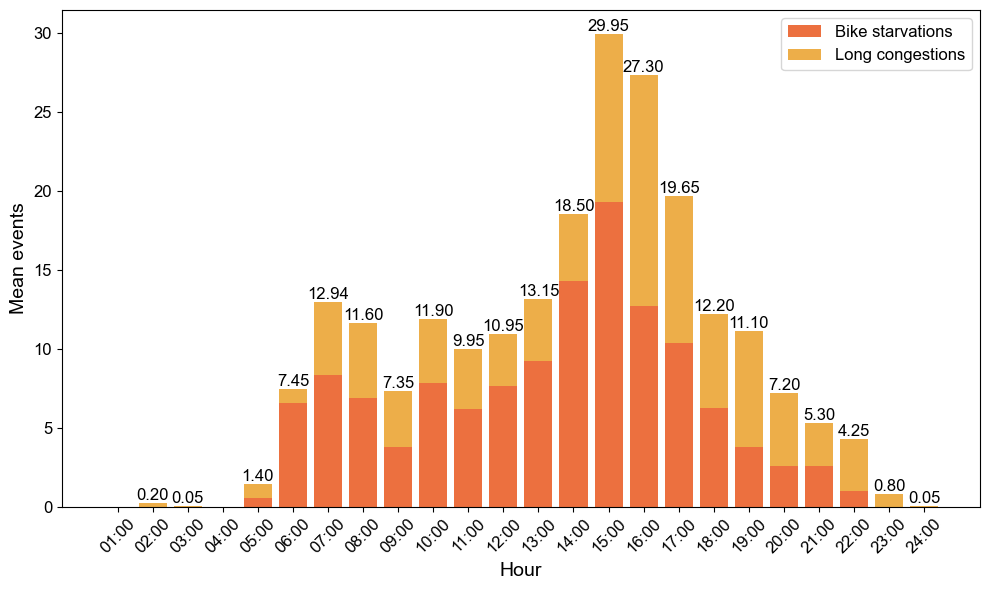

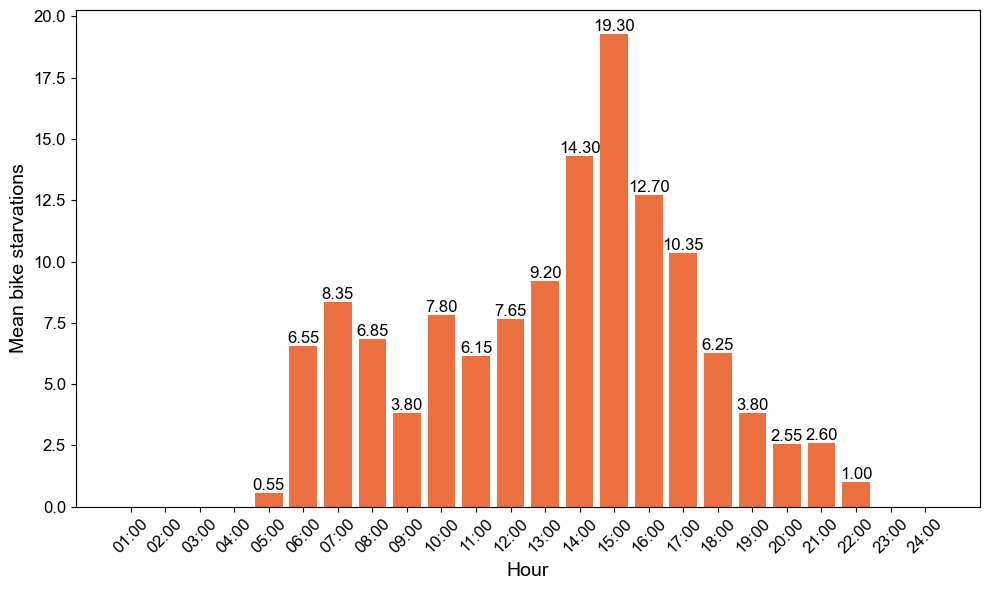

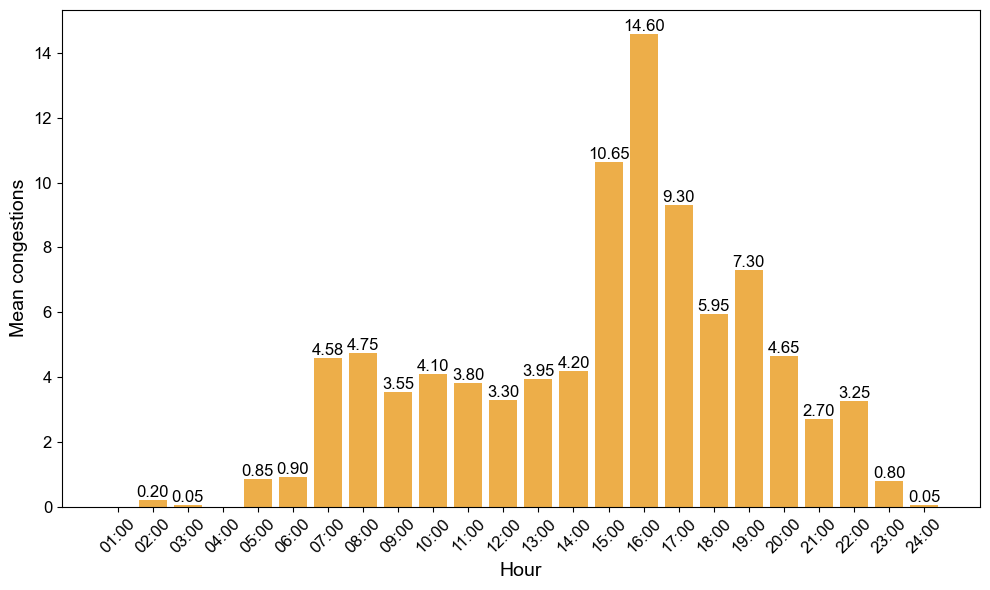

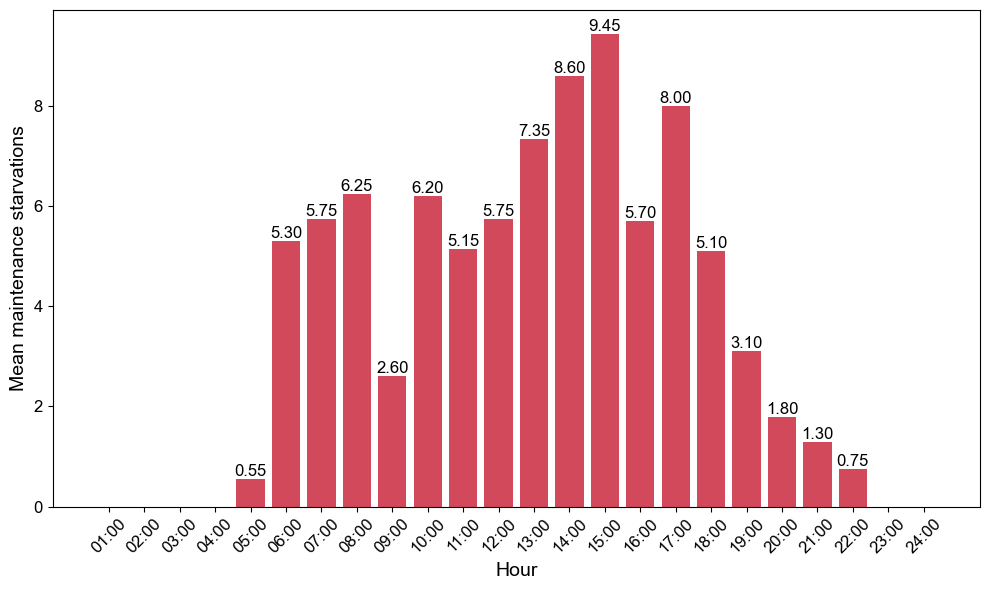

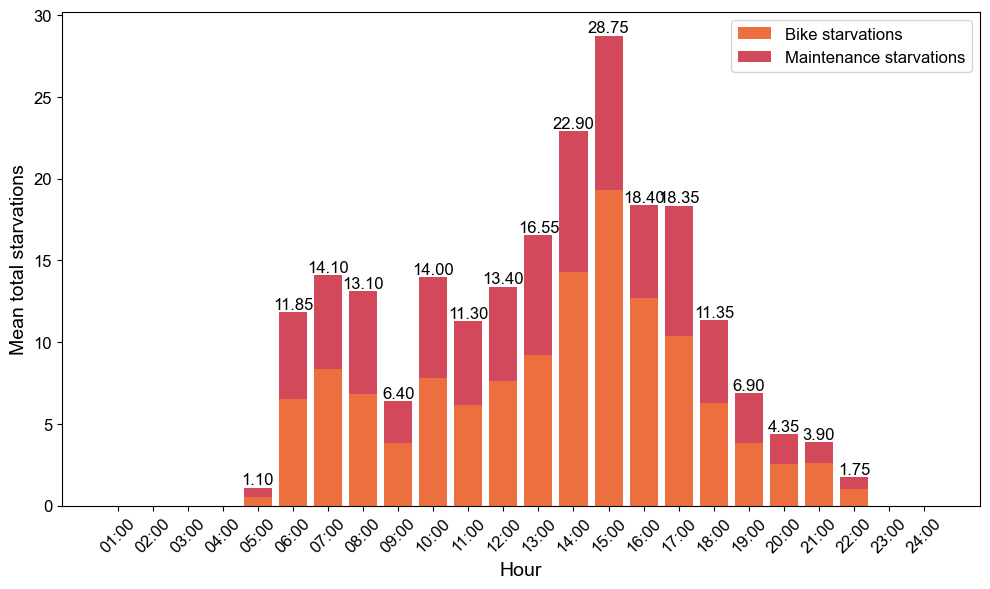

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTIONS
# ---------------------------
def plot_hourly_stacked_events(df_hourly, title_label):
    """
    Plots a stacked bar chart of Mean Bike Starvations (bottom) 
    and Mean Long Congestions (top) by hour.
    """
    # ---------------------------
    # 1. Data Processing
    # ---------------------------

    # Sum both metrics for each (Day, Hour) pair
    # (If df_hourly is averaged, this is the average sum per day)
    hourly_sums = (
        df_hourly.groupby(["Day", "Hour"])[["Bike Starvations", "Long Congestions"]]
        .sum()
        .reset_index()
    )

    # Compute mean per hour across all days
    mean_hourly = (
        hourly_sums.groupby("Hour")[["Bike Starvations", "Long Congestions"]]
        .mean()
        .reset_index()
    )

    # Extract lists
    hours = mean_hourly["Hour"].tolist()
    starv_vals = mean_hourly["Bike Starvations"].tolist()
    cong_vals = mean_hourly["Long Congestions"].tolist()

    # Calculate total height for labeling and axis limits
    total_vals = [s + c for s, c in zip(starv_vals, cong_vals)]

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # ---------------------------
    # 2. Plotting
    # ---------------------------

    plt.figure(figsize=(10, 6))

    # Define colors
    color_cong = activity_colors["Congestions"]
    color_starv = activity_colors["Bike_starvations"]

    # Plot Bottom Bar (Starvations)
    p1 = plt.bar(hour_labels, starv_vals, color=color_starv, label="Bike starvations", alpha=1.0, width=0.8)

    # Plot Top Bar (Congestions) - use 'bottom' parameter to stack on starvations
    p2 = plt.bar(hour_labels, cong_vals, bottom=starv_vals, color=color_cong, label="Long congestions", alpha=1.0, width=0.8)

    # ---------------------------
    # 3. Formatting
    # ---------------------------

    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean events", fontsize=14)
    #plt.title(f"Hourly Stacked Events: {title_label}", fontsize=16, pad=20)
    plt.legend(fontsize=12, loc='upper right')

    # Label the TOTAL height on top of the stack
    for h, total in zip(hour_labels, total_vals):
        if total > 0.0: # Only label significant totals
            plt.text(h, total,
                     f"{total:.2f}",
                     ha='center', va='bottom',
                     color='black', fontsize=12)

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    #plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"stacked_starvations_congestions_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()


def plot_mean_events(df_hourly, title_label):
    """
    Plots 4 additional bar charts showing mean over all hours for different event types.
    """
    # Data Processing
    hourly_sums = (
        df_hourly.groupby(["Day", "Hour"])[["Bike Starvations", "Maintenance Starvations", "Long Congestions"]]
        .sum()
        .reset_index()
    )
    
    mean_hourly = (
        hourly_sums.groupby("Hour")[["Bike Starvations", "Maintenance Starvations", "Long Congestions"]]
        .mean()
        .reset_index()
    )
    
    hours = mean_hourly["Hour"].tolist()
    hour_labels = [f"{int(h):02d}:00" for h in hours]
    bike_starv = mean_hourly["Bike Starvations"].tolist()
    maint_starv = mean_hourly["Maintenance Starvations"].tolist()
    congestions = mean_hourly["Long Congestions"].tolist()
    
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    # Color definitions
    color_sunset_orange = activity_colors["Bike_starvations"]  # Sunset orange
    color_gold = activity_colors["Congestions"]          # Gold
    color_warm_red = activity_colors["Maint_starvations"]   # Warm red
    
    # 1. Bike starvations alone
    plt.figure(figsize=(10, 6))
    plt.bar(hour_labels, bike_starv, color=color_sunset_orange, alpha=1.0, width=0.8)
    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean bike starvations", fontsize=14)
    for h, v in zip(hour_labels, bike_starv):
        if v > 0.0:
            plt.text(h, v, f"{v:.2f}", ha='center', va='bottom', color='black', fontsize=12)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.savefig(f"mean_bike_starvations_{safe_label}.svg", bbox_inches='tight', pad_inches=0.02)
    plt.show()
    
    # 2. Congestions alone
    plt.figure(figsize=(10, 6))
    plt.bar(hour_labels, congestions, color=color_gold, alpha=1.0, width=0.8)
    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean congestions", fontsize=14)
    for h, v in zip(hour_labels, congestions):
        if v > 0.0:
            plt.text(h, v, f"{v:.2f}", ha='center', va='bottom', color='black', fontsize=12)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.savefig(f"mean_congestions_{safe_label}.svg", bbox_inches='tight', pad_inches=0.02)
    plt.show()
    
    # 3. Maintenance starvations alone
    plt.figure(figsize=(10, 6))
    plt.bar(hour_labels, maint_starv, color=color_warm_red, alpha=1.0, width=0.8)
    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean maintenance starvations", fontsize=14)
    for h, v in zip(hour_labels, maint_starv):
        if v > 0.0:
            plt.text(h, v, f"{v:.2f}", ha='center', va='bottom', color='black', fontsize=12)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.savefig(f"mean_maint_starvations_{safe_label}.svg", bbox_inches='tight', pad_inches=0.02)
    plt.show()
    
    # 4. Total starvations stacked (bike + maintenance)
    plt.figure(figsize=(10, 6))
    plt.bar(hour_labels, bike_starv, color=color_sunset_orange, label="Bike starvations", alpha=1.0, width=0.8)
    plt.bar(hour_labels, maint_starv, bottom=bike_starv, color=color_warm_red, label="Maintenance starvations", alpha=1.0, width=0.8)
    plt.xlabel("Hour", fontsize=14)
    plt.ylabel("Mean total starvations", fontsize=14)
    plt.legend(fontsize=12, loc='upper right')
    total_starv = [b + m for b, m in zip(bike_starv, maint_starv)]
    for h, total in zip(hour_labels, total_starv):
        if total > 0.0:
            plt.text(h, total, f"{total:.2f}", ha='center', va='bottom', color='black', fontsize=12)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.savefig(f"mean_total_starvations_stacked_{safe_label}.svg", bbox_inches='tight', pad_inches=0.02)
    plt.show()


# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Event plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot all visualizations
    print(f"   -> Plotting {label_text}...")
    plot_hourly_stacked_events(
        df_hourly=current_hourly_df,
        title_label=label_text
    )
    plot_mean_events(
        df_hourly=current_hourly_df,
        title_label=label_text
    )

# 5 Vehicle insight

In [ ]:


# ---------------------------
# 1. METRIC FUNCTION
# ---------------------------
def calculate_vehicle_metrics(df_vehicle, scale_factor=1):
    """
    Calculates summary metrics for vehicle visits.
    
    Args:
        df_vehicle: DataFrame containing vehicle log.
        scale_factor: int. Used to normalize total counts if df_vehicle contains 
                      stacked data from multiple seeds.
    """
    # 1. Total Visits (Normalized)
    raw_visits = df_vehicle.shape[0]
    avg_visits = raw_visits / scale_factor
    
    # 2. Unique Stations Visited
    # For "average" (stacked) data, this shows the union of all stations visited across all runs.
    unique_stations = df_vehicle["Station ID"].nunique()
    
    return {
        "Avg Visits/Week": round(avg_visits, 1),
        "Unique Stations": unique_stations
    }

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"\n{'='*20} VEHICLE VISIT SUMMARY COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

comparison_list = []

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Determine Scale Factor
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str)
        scale = len(seeds_used)
    else:
        scale = 1
        
    # 2. Calculate Metrics
    stats = calculate_vehicle_metrics(
        df_vehicle=data_dict["vehicle"],
        scale_factor=scale
    )
    
    # 3. Add Identity info
    stats["Alpha"] = alpha_val
    comparison_list.append(stats)

# ---------------------------
# 3. DISPLAY RESULTS
# ---------------------------
if comparison_list:
    # Create DataFrame
    results_df = pd.DataFrame(comparison_list)
    
    # Reorder columns
    cols = ["Alpha", "Avg Visits/Week", "Unique Stations"]
    results_df = results_df[cols]
    
    print("\n")
    print(results_df.to_string(index=False))
    
else:
    print("No data available.")

print("="*60)


==================== VEHICLE VISIT SUMMARY COMPARISON ====================
Aggregation Mode: average
DEBUG: Found seeds for alpha 0.250: [1, 2, 3, 4]


 Alpha  Avg Visits/Week  Unique Stations
  0.25            430.8               56


In [ ]:
# ---------------------------
# 1. SETUP BASE DATAFRAME
# ---------------------------
# Ensure we have the integer ID in the base stations_df for merging
if "id" not in stations_df.columns:
    # Assuming stations_df["id"] might be missing or text "S1", "S2"...
    # We try to use the index or a specific column if it exists, 
    # but based on previous cells, 'id' is likely just the row index or needed extraction.
    # Let's create it safely:
    stations_df["id"] = stations_df.index # If index is 0, 1, 2...
    # OR if you have a "Station ID" column like "S0":
    # stations_df["id"] = stations_df["Station ID"].str.extract(r"S(\d+)").astype(int)

# Create a master DataFrame indexed by Station ID
visit_comparison = stations_df[["id", "lat", "lon"]].copy().set_index("id")

print(f"Calculating Station Visits for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

# ---------------------------
# 2. LOOP THROUGH ALPHAS
# ---------------------------
for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get Vehicle Data
    df_vehicle = data_dict["vehicle"].copy()
    
    if df_vehicle.empty:
        print(f"Warning: No vehicle data for Alpha {alpha_val}")
        visit_comparison[f"Alpha {alpha_val}"] = 0.0
        continue

    # 2. Extract numeric id: "S35" -> 35
    # We use regex to be safe
    df_vehicle["id"] = df_vehicle["Station ID"].astype(str).str.extract(r"S(\d+)").astype(int)

    # 3. Count visits per station id
    # This gives the total count across ALL seeds in the dataframe
    station_counts = df_vehicle.groupby("id").size()

    # 4. Normalize if Average Mode
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str)
        scale = len(seeds_used)
        
        # Calculate Average Visits per Run
        station_counts = station_counts / scale
    
    # 5. Add to the Master Comparison DataFrame
    # This automatically aligns indices (Station IDs)
    col_name = f"Alpha {alpha_val}"
    visit_comparison[col_name] = station_counts

# ---------------------------
# 3. CLEANUP AND DISPLAY
# ---------------------------

# Fill NaN with 0 (stations that were never visited)
visit_comparison = visit_comparison.fillna(0)

# Sort by the first Alpha column just to show most active stations at the top
first_alpha_col = f"Alpha {list(alpha_results.keys())[0]}"
visit_comparison = visit_comparison.sort_values(by=first_alpha_col, ascending=False)

# Round to 1 decimal place for cleaner viewing
print(f"\nTop 70 Stations by Vehicle Visits (Sorted by {first_alpha_col}):")
print(visit_comparison.drop(columns=["lat", "lon"]).round(1).head(70))

Calculating Station Visits for 1 Alpha scenarios...
Mode: average
DEBUG: Found seeds for alpha 0.250: [1, 2, 3, 4]

Top 70 Stations by Vehicle Visits (Sorted by Alpha 0.25):
    Alpha 0.25
id            
37        24.2
31        23.2
60        18.8
63        18.5
41        17.5
..         ...
25         0.0
9          0.0
13         0.0
14         0.0
17         0.0

[67 rows x 1 columns]


## 5.1 Unique stations visited per hour

Generating Visit Heatmaps for 1 Alpha scenarios...
Mode: average
DEBUG: Found seeds for alpha 0.250: [1, 2, 3, 4]
   -> Plotting Alpha 0.25 (average)...


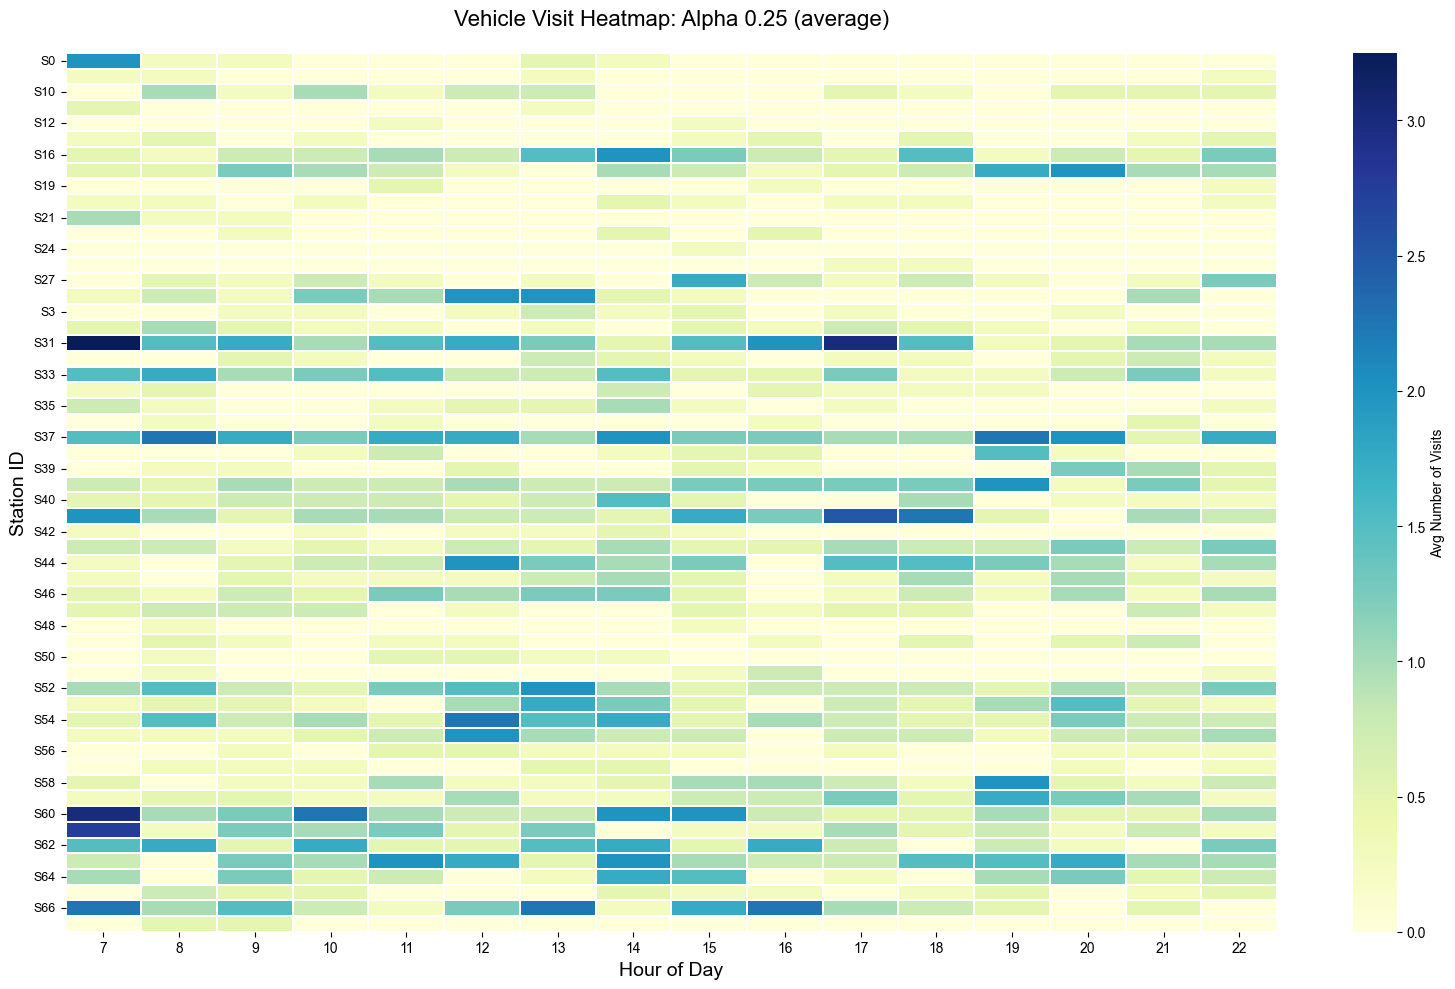

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_visit_heatmap(df_vehicle, title_label, scale_factor=1):
    """
    Plots a heatmap of vehicle visits (Station ID vs Hour).
    
    Args:
        df_vehicle: DataFrame containing vehicle log.
        title_label: String label for the chart.
        scale_factor: int. Used to normalize visit counts if df_vehicle contains 
                      stacked data from multiple seeds.
    """
    # 1. Count visits per station per hour
    visits_matrix = (
        df_vehicle.groupby(["Station ID", "Hour"])
        .size()
        .reset_index(name="visits")
    )
    
    # Normalize counts if using stacked data (Average Mode)
    if scale_factor > 1:
        visits_matrix["visits"] = visits_matrix["visits"] / scale_factor

    # 2. Pivot to station x hour matrix
    heatmap_data = visits_matrix.pivot(index="Station ID", columns="Hour", values="visits")

    # Replace NaN with 0
    heatmap_data = heatmap_data.fillna(0)
    
    # Sort Index (Stations) for cleaner view
    # (Optional: If you want numeric sorting S1->S2->S10, extra logic is needed. 
    # Standard sort gives S1->S10->S2)
    heatmap_data = heatmap_data.sort_index()

    # 3. Plotting
    plt.figure(figsize=(16, 10))
    
    ax = sns.heatmap(
        heatmap_data,
        cmap="YlGnBu",
        linewidths=0.01,
        cbar_kws={"label": "Avg Number of Visits" if scale_factor > 1 else "Number of Visits"}
    )

    plt.title(f"Vehicle Visit Heatmap: {title_label}", fontsize=16, pad=20)
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Station ID", fontsize=14)

    plt.xticks(rotation=0) # Keep hour labels horizontal
    plt.yticks(rotation=0, fontsize=9) # Keep station labels horizontal
    
    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.tight_layout()
    plt.savefig(
        f"vehicle_visit_heatmap_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Visit Heatmaps for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Determine Scale Factor
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str)
        scale = len(seeds_used)
    else:
        scale = 1
        
    # 2. Get Data
    df_vehicle = data_dict["vehicle"]
    
    # 3. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 4. Plot
    print(f"   -> Plotting {label_text}...")
    plot_visit_heatmap(
        df_vehicle=df_vehicle,
        title_label=label_text,
        scale_factor=scale
    )

## 5.2 Plot over visit frequency on map

In [ ]:
# ---------------------------
# 1. DEFINE COLOR FUNCTION
# ---------------------------
def visit_color(n):
    if n == 0:
        return "lightgray" # Changed slightly to be distinct for 0
    elif n < 1: 
        return "lightgreen" # For very low averages (e.g. 0.5 visits)
    elif 1 <= n <= 5:
        return "#f7f148"    # Yellow
    elif 6 <= n <= 15:
        return "#f3903f"    # Orange
    elif 16 <= n <= 25:
        return "#ed683c"    # Dark Orange
    else:
        return "#ce0011"    # Red

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Vehicle Visit Maps for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # --- A. Prepare Data for this Alpha ---
    df_vehicle = data_dict["vehicle"].copy()
    
    # 1. Extract numeric ID from "S10" -> 10
    df_vehicle["id"] = df_vehicle["Station ID"].astype(str).str.extract(r"S(\d+)").astype(int)

    # 2. Count visits per station
    counts = df_vehicle.groupby("id").size().reset_index(name="num_visits")
    
    # 3. Normalize if Average Mode
    # (We want the map to show "Avg Visits per Run", not total sum across 10 runs)
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        scale = len(get_available_seeds(alpha_str))
        counts["num_visits"] = counts["num_visits"] / scale
    
    # 4. Merge with Station Coordinates (lat/lon)
    # Ensure stations_df has 'id' column
    if "id" not in stations_df.columns:
        # Fallback if 'id' isn't set yet
        stations_df["id"] = stations_df.index 
        
    map_data = stations_df.merge(counts, on="id", how="left")
    map_data["num_visits"] = map_data["num_visits"].fillna(0)

    # --- B. Create Map ---
    
    # Center map on mean lat/lon
    center_lat = map_data["lat"].mean()
    center_lon = map_data["lon"].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

    # Calculate dynamic radius parameters
    max_visits = map_data["num_visits"].max()
    min_radius = 5
    max_radius = 20 if max_visits > 0 else 6

    # Add Markers
    for _, row in map_data.iterrows():
        n = row["num_visits"]
        
        # Scale radius
        radius = min_radius
        if max_visits > 0:
            radius = min_radius + (n / max_visits) * (max_radius - min_radius)

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=radius,
            fill=True,
            color=visit_color(n),
            fill_color=visit_color(n),
            fill_opacity=0.8,
            popup=(
                f"Station S{int(row['id'])}<br>"
                f"Alpha: {alpha_val}<br>"
                f"Visits: {n:.1f}" # formatted to 1 decimal
            ),
        ).add_to(m)

    # --- C. Save Map ---
    
    # Create unique filename
    mode_label = f"seed_{selection_mode}" if isinstance(selection_mode, int) else selection_mode
    filename = f"vehicle_visits_map_{mode_label}_Alpha_{alpha_val}.html"
    
    m.save(filename)
    print(f"   -> Saved: {filename}")

print("\nDone.")

Generating Vehicle Visit Maps for 1 Alpha scenarios...
Mode: average
DEBUG: Found seeds for alpha 0.250: [1, 2, 3, 4]
   -> Saved: vehicle_visits_map_average_Alpha_0.25.html

Done.


## 5.3 Vehicle maintenance allocation

Generating Maintenance Timelines for 1 Alpha scenarios...
Mode: average
   -> Plotting Alpha 0.25 (average)...


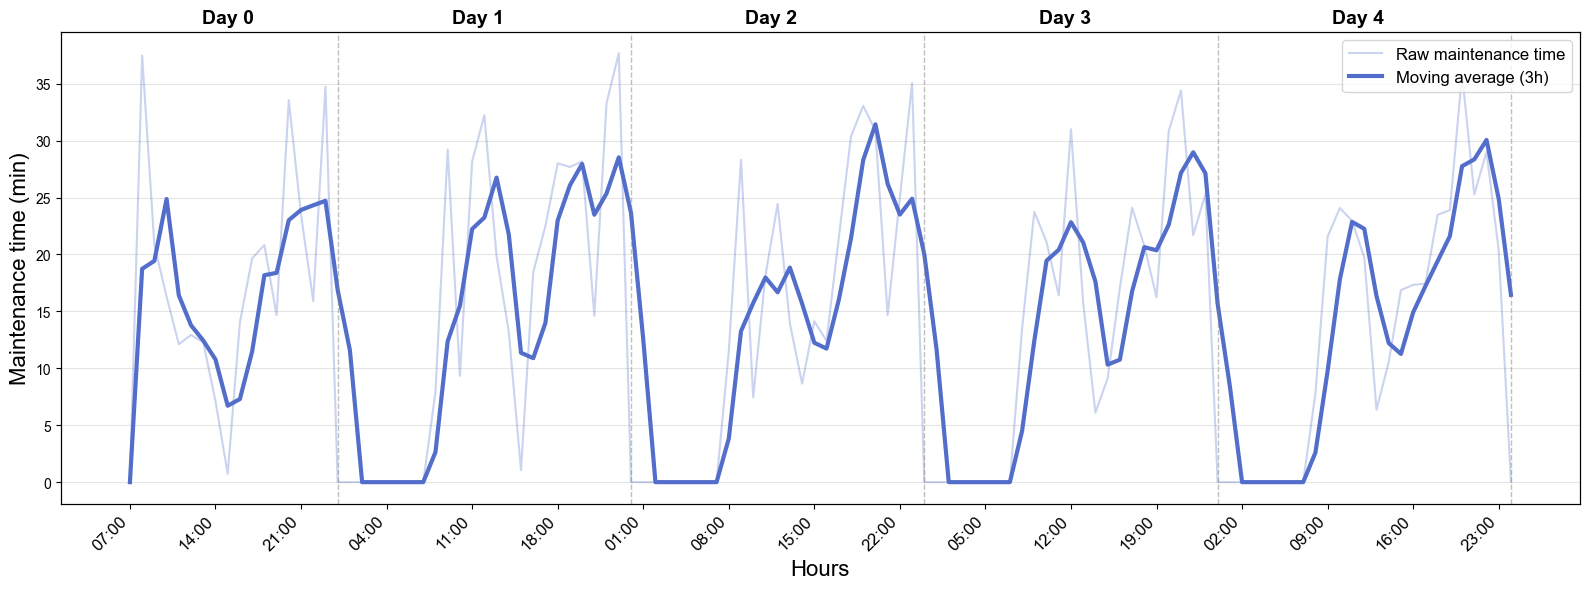

In [ ]:


# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_maintenance_timeline(df_hourly, title_label):
    """
    Plots the timeline of Maintenance Time (Raw vs Moving Average).
    Includes logic to cap at Day 4 + 1 Hour for a clean visual finish.
    """
    # 1. PREPARE DATA & APPLY CAP
    g = apply_time_cap(df_hourly).copy()
    
    if g.empty:
        print(f"Warning: No data for {title_label} after filtering.")
        return
    
    # Ensure sorting by time
    if "Time (minutes)" in g.columns:
        g = g.sort_values("Time (minutes)")
    else:
        g = g.sort_values(["Day", "Hour"])
        
    g = g.reset_index(drop=True)
    
    # Calculate Moving Average (Window = 3 hours)
    g["Maintenance_MA"] = g["Maintenance Time (minutes)"].rolling(window=3, min_periods=1).mean()
    
    # Create Label for bottom axis
    g["hour_label"] = g["Hour"].astype(int).astype(str).str.zfill(2) + ":00"

    # 2. IDENTIFY DAY BOUNDARIES
    # Find indices where the day changes (Day i != Day i-1)
    day_change_idx = g.index[g["Day"].ne(g["Day"].shift())].tolist()
    
    # Skip the very first index (0) if it's the start of the sim
    boundary_positions = day_change_idx[1:]

    # 3. CALCULATE DAY CENTERS (For Top Axis)
    day_centers = []
    day_labels = []
    for day_val in g["Day"].unique():
        # Skip Day 5 label if it's just the single cutoff point
        if CAP_AT_DAY_4 and day_val >= 5:
            continue
            
        idxs = g.index[g["Day"] == day_val]
        if len(idxs) > 0:
            center = (idxs[0] + idxs[-1]) / 2
            day_centers.append(center)
            day_labels.append(f"Day {int(day_val)}")

    # 4. PLOTTING
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Use the reference color (Olive Green/Blueish depending on palette)
    line_color = activity_colors["Maintenance"]
    x = g.index 

    # Plot Raw values (Low Alpha)
    ax.plot(x, g["Maintenance Time (minutes)"], alpha=0.3, 
            label="Raw maintenance time", color=line_color)

    # Plot Moving average (Thick line)
    ax.plot(x, g["Maintenance_MA"], linewidth=3, color=line_color, 
            label="Moving average (3h)")

    # Vertical lines (Day boundaries)
    for pos in boundary_positions:
        ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    # --- Y-AXIS GRID & FORMATTING ---
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10)) 
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.2, color='gray')
    ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')
    
    ax.set_ylabel("Maintenance time (min)", fontsize=16)
    ax.set_xlabel("Hours", fontsize=16)

    # --- BOTTOM X-AXIS (Hours) ---
    # Calculate step to prevent label overlap.
    denom = 15 if CAP_AT_DAY_4 else 25
    step = max(1, len(g) // denom)
    
    ax.set_xticks(list(x)[::step])
    #ax.set_xticklabels(g["hour_label"].iloc[::step],rotation=45, ha="right", fontsize=1)
    ax.set_xticklabels(g["hour_label"].iloc[::step], rotation=45, ha="right", fontsize=12)

    # --- TOP X-AXIS (Day Labels) ---
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim()) # Sync limits exactly
    ax2.set_xticks(day_centers)
    ax2.set_xticklabels(day_labels, fontsize=14, fontweight='bold')
    
    ax2.xaxis.set_ticks_position("top")
    ax2.xaxis.set_label_position("top")
    ax2.tick_params(axis='x', length=0) # Hide tick marks

    ax.legend(loc="upper right", frameon=True, fontsize=12)
    

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.tight_layout()
    plt.savefig(
        f"maintenance_time_{safe_label}_capped_{CAP_AT_DAY_4}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Maintenance Timelines for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_maintenance_timeline(
        df_hourly=current_hourly_df,
        title_label=label_text
    )

### 5.3.1 Maintenance allocation each day

In [ ]:
# print maintenance time in minutes for each alpha each day of the week
print(f"\n{'='*20} MAINTENANCE TIME SUMMARY {'='*20}")
for alpha_val, data_dict in alpha_results.items():  
    current_hourly_df = data_dict["hourly"]
    maint_by_day = (
        current_hourly_df.groupby("Day")["Maintenance Time (minutes)"]
        .sum()
        .reset_index()
    )
    print(f"\nAlpha {alpha_val} Maintenance Time by Day:")
    for _, row in maint_by_day.iterrows():
        print(f"  Day {int(row['Day'])}: {row['Maintenance Time (minutes)']:.1f} minutes")
        


==================== MAINTENANCE TIME SUMMARY ====================

Alpha 0.0 Maintenance Time by Day:
  Day 0: 0.0 minutes
  Day 1: 0.0 minutes
  Day 2: 0.0 minutes
  Day 3: 0.0 minutes
  Day 4: 0.0 minutes
  Day 5: 0.0 minutes


##5.4 Fleet criticality development of one alpha


Preparing Criticality Plot with Trend Line...


Preparing Criticality Plot with Trend Line...


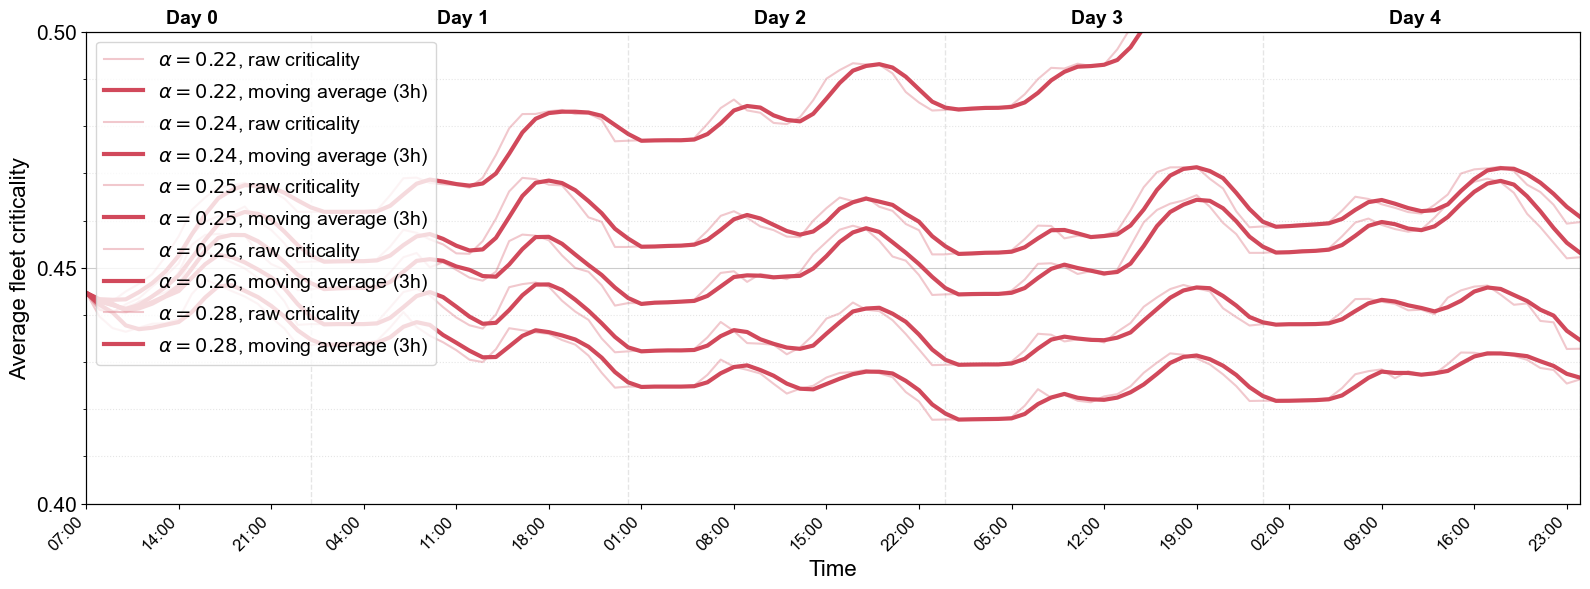

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
 
 
# ---------------------------
# 1. HELPER FUNCTION
# ---------------------------
def process_crit_data(df, window=3):
    """
    Cleans the dataframe, trims start time, and calculates Moving Average.
    """
    #c = apply_time_cap(df).copy()
    c = df[["Day", "Hour", "Avg Bike Criticality"]]
   
    # Fix incorrect hour value "24" -> Hour 0
    mask_24 = c["Hour"] == 24
    c.loc[mask_24, "Hour"] = 0
   
    # Sort cleanly
    c = c.sort_values(["Day", "Hour"]).reset_index(drop=True)
 
    # --- FILTER START TIME (Start at 07:00 on the first day) ---
    min_day = c["Day"].min()
    mask_start = (c["Day"] > min_day) | ((c["Day"] == min_day) & (c["Hour"] >= 0))
    c = c[mask_start].reset_index(drop=True)
   
    # Moving Average
    c["MA"] = c["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()
    c["hour_label"] = c["Hour"].astype(str).str.zfill(2) + ":00"
   
    return c
 
# ---------------------------
# 2. DATA PREPARATION
# ---------------------------
window_size = 3
plot_datasets = []
SHOW_TRENDLINE = False  # Set to True to show trendline, False to hide
TRENDLINE_DATASET_INDEX = 0  # Which dataset to use for trend (0 = first alpha)
 
print(f"Preparing Criticality Plot with Trend Line...")
 
for i, (alpha_val, data_dict) in enumerate(alpha_results.items()):
    raw_df = data_dict["hourly"]
    processed_df = process_crit_data(raw_df, window=window_size)
   
    # CYCLE THROUGH CUSTOM COLORS
    color_tuple = colors[i % len(colors)]
    hex_color = color_tuple[1]
   
    label_text = rf"$\alpha = {alpha_val}$"
    plot_datasets.append((label_text, processed_df, hex_color))
 
# ---------------------------
# 3. IDENTIFY X-AXIS & BOUNDARIES
# ---------------------------
if not plot_datasets:
    raise ValueError("No data found to plot.")
 
ref_df = plot_datasets[0][1]
x_ref = ref_df.index
 
# Find day boundaries
day_change_idx = ref_df.index[ref_df["Day"].ne(ref_df["Day"].shift())].tolist()
boundary_positions = [x for x in day_change_idx if x > 0]
 
day_centers = []
day_labels = []
for day_val in ref_df["Day"].unique():
    # Skip Day 5 label if it's just the single cutoff point
    if CAP_AT_DAY_4 and day_val >= 5:
        continue
        
    idxs = ref_df.index[ref_df["Day"] == day_val]
    if len(idxs) > 0:
        center = (idxs[0] + idxs[-1]) / 2
        day_centers.append(center)
        day_labels.append(f"Day {int(day_val)}")
 
# ---------------------------
# 4. PLOTTING
# ---------------------------
fig, ax = plt.subplots(figsize=(16, 6))
 
# Use the Criticality color from activity_colors
line_color = activity_colors["Criticality"]

for label, df, color in plot_datasets:
    x = df.index
    
    # Plot Raw values (Low Alpha) - similar to cell 55 style
    ax.plot(x, df["Avg Bike Criticality"], alpha=0.3, 
            label=f"{label}, raw criticality", color=line_color)
    
    # Plot Moving average (Thick line) - similar to cell 55 style
    ax.plot(x, df["MA"], linewidth=3, color=line_color, 
            label=f"{label}, moving average (3h)")
 
# --- 4b. ADD TREND LINE (OPTIONAL) ---
if SHOW_TRENDLINE:
    # Calculate the trend based on selected dataset
    trend_source_df = plot_datasets[TRENDLINE_DATASET_INDEX][1]
    trend_label = plot_datasets[TRENDLINE_DATASET_INDEX][0]
    
    # Create x values (0, 1, 2...) matching the index
    x_trend = np.arange(len(trend_source_df))
    y_trend = trend_source_df["MA"].fillna(method='bfill')  # Fill NaNs for calculation
    
    # Calculate Linear Regression (Polyfit degree 1)
    slope, intercept = np.polyfit(x_trend, y_trend, 1)
    
    # Generate Y values for the line
    trend_line_y = slope * x_trend + intercept
    
    # Plot the trend line
    ax.plot(x_trend, trend_line_y, color="black", linestyle="--", linewidth=2,
            label=f"Trend ({trend_label}): slope={slope:.7f}", alpha=0.6)
# ----------------------------------------
 
 
# Vertical lines (Day boundaries)
for pos in boundary_positions:
    ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.2)
 
# ---------------------------
# AXIS SETTINGS
# ---------------------------
 
# 1. X-Axis Limits (No Gap)
ax.set_xlim(x_ref[0], x_ref[-1])
 
# 2. Y-Axis Limits
ax.set_ylim(0.40, 0.50)
 
# 3. Granular Ticks
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
 
# Grid settings
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.4, color='gray')
ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')
 
# FONT SIZES
ax.set_ylabel("Average fleet criticality", fontsize=16)
ax.set_xlabel("Time", fontsize=16)
 
# --- BOTTOM X-AXIS (Hours) ---
# Calculate step to prevent label overlap
denom = 15 if CAP_AT_DAY_4 else 25
step = max(1, len(ref_df) // denom)
    
ax.set_xticks(list(x_ref)[::step])
ax.set_xticklabels(ref_df["hour_label"].iloc[::step], 
                   rotation=45, ha="right", fontsize=12)

# --- TOP X-AXIS (Day Labels) ---
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())  # Sync limits exactly
ax2.set_xticks(day_centers)
ax2.set_xticklabels(day_labels, fontsize=14, fontweight='bold')
    
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")
ax2.tick_params(axis='x', length=0)  # Hide tick marks

# Y-axis tick label size
ax.tick_params(axis='y', labelsize=15)
 
# Legend positioning
ax.legend(loc='upper left', fontsize=14)
 
# 6. SAVE
plt.tight_layout()
 
filename = f"average_fleet_criticality_{alpha_val}_movingaverage.svg"
plt.savefig(
    filename,
    bbox_inches='tight',
    pad_inches=0.02
)
 
plt.show()


Preparing Criticality Plot with Trend Line...


C:\Users\ingvivsu\AppData\Local\Temp\ipykernel_21464\3964536024.py:111: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_trend = trend_source_df["MA"].fillna(method='bfill')  # Fill NaNs for calculation


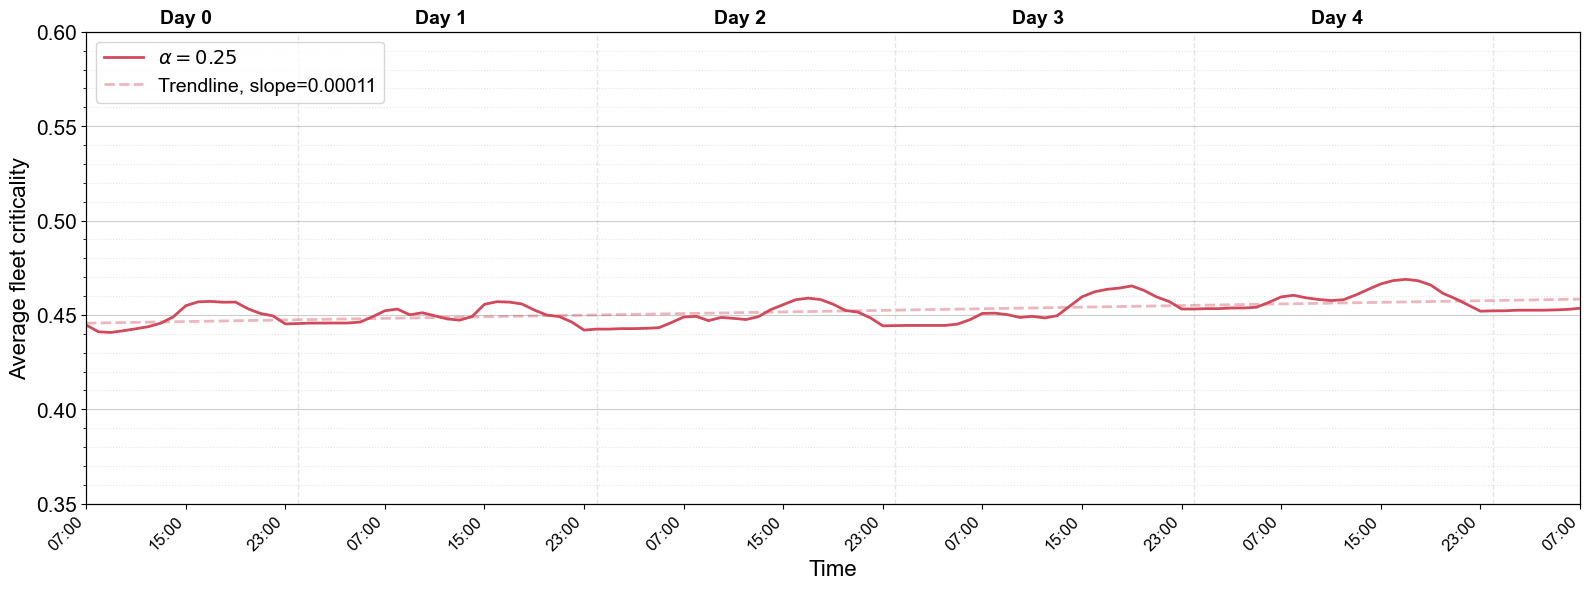

In [ ]:
#For å lage en linjeplot med trendlinje for gjennomsnittlig flåtekritikalitet over tid
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

colors = [
    #("Sunset Orange", "#FF7038"), #Uncomment for alpha = 0.0
    ("Warm Red", "#D1495B"),
]

 
# ---------------------------
# 1. HELPER FUNCTION
# ---------------------------
def process_crit_data(df, window=3):
    """
    Cleans the dataframe, trims start time, and calculates Moving Average.
    """
    #c = apply_time_cap(df).copy()
    c = df[["Day", "Hour", "Avg Bike Criticality"]]
   
    # Fix incorrect hour value "24" -> Hour 0
    mask_24 = c["Hour"] == 24
    c.loc[mask_24, "Hour"] = 0
   
    # Sort cleanly
    c = c.sort_values(["Day", "Hour"]).reset_index(drop=True)
 
    # --- FILTER START TIME (Start at 07:00 on the first day) ---
    min_day = c["Day"].min()
    mask_start = (c["Day"] > min_day) | ((c["Day"] == min_day) & (c["Hour"] >= 0))
    c = c[mask_start].reset_index(drop=True)
   
    # Moving Average
    c["MA"] = c["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()
    c["hour_label"] = c["Hour"].astype(str).str.zfill(2) + ":00"
   
    return c
 
# ---------------------------
# 2. DATA PREPARATION
# ---------------------------
window_size = 3
plot_datasets = []
SHOW_TRENDLINE = True  # Set to True to show trendline, False to hide
TRENDLINE_DATASET_INDEX = 0  # Which dataset to use for trend (0 = first alpha)
 
print(f"Preparing Criticality Plot with Trend Line...")
 
for i, (alpha_val, data_dict) in enumerate(alpha_results.items()):
    raw_df = data_dict["hourly"]
    processed_df = process_crit_data(raw_df, window=window_size)
   
    # CYCLE THROUGH CUSTOM COLORS
    color_tuple = colors[i % len(colors)]
    hex_color = color_tuple[1]
   
    label_text = rf"$\alpha = {alpha_val}$"
    plot_datasets.append((label_text, processed_df, hex_color))
 
# ---------------------------
# 3. IDENTIFY X-AXIS & BOUNDARIES
# ---------------------------
if not plot_datasets:
    raise ValueError("No data found to plot.")
 
ref_df = plot_datasets[0][1]
x_ref = ref_df.index
 
# Find day boundaries
day_change_idx = ref_df.index[ref_df["Day"].ne(ref_df["Day"].shift())].tolist()
boundary_positions = [x for x in day_change_idx if x > 0]
 
day_centers = []
day_labels = []
for day_val in ref_df["Day"].unique():
    # Skip Day 5 label if it's just the single cutoff point
    if CAP_AT_DAY_4 and day_val >= 5:
        continue
        
    idxs = ref_df.index[ref_df["Day"] == day_val]
    if len(idxs) > 0:
        center = (idxs[0] + idxs[-1]) / 2
        day_centers.append(center)
        day_labels.append(f"Day {int(day_val)}")
 
# ---------------------------
# 4. PLOTTING
# ---------------------------
fig, ax = plt.subplots(figsize=(16, 6))
 
# Use Warm Red color
line_color = colors[0][1]  # Warm Red

for label, df, color in plot_datasets:
    x = df.index
    
    # Plot main line with Warm Red
    ax.plot(x, df["Avg Bike Criticality"], linewidth=2, 
            label=label, color=line_color)
    
# --- 4b. ADD TREND LINE (OPTIONAL) ---
if SHOW_TRENDLINE:
    # Calculate the trend based on selected dataset
    trend_source_df = plot_datasets[TRENDLINE_DATASET_INDEX][1]
    trend_label = plot_datasets[TRENDLINE_DATASET_INDEX][0]
    
    # Create x values (0, 1, 2...) matching the index
    x_trend = np.arange(len(trend_source_df))
    y_trend = trend_source_df["MA"].fillna(method='bfill')  # Fill NaNs for calculation
    
    # Calculate Linear Regression (Polyfit degree 1)
    slope, intercept = np.polyfit(x_trend, y_trend, 1)
    
    # Generate Y values for the line
    trend_line_y = slope * x_trend + intercept
    
    # Plot the trend line with same Warm Red color but lower opacity
    ax.plot(x_trend, trend_line_y, color=line_color, linestyle="--", linewidth=2,
            label=f"Trendline, slope={slope:.5f}", alpha=0.4)
# ----------------------------------------
 
 
# Vertical lines (Day boundaries)
for pos in boundary_positions:
    ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.2)
 
# ---------------------------
# AXIS SETTINGS
# ---------------------------
 
# 1. X-Axis Limits (No Gap)
ax.set_xlim(x_ref[0], x_ref[-1])
 
# 2. Y-Axis Limits
ax.set_ylim(0.35, 0.6)
 
# 3. Granular Ticks
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
 
# Grid settings
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.4, color='gray')
ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')
 
# FONT SIZES
ax.set_ylabel("Average fleet criticality", fontsize=16)
ax.set_xlabel("Time", fontsize=16)
 
# --- BOTTOM X-AXIS (Hours) ---
# Calculate step to prevent label overlap
denom = 15 if CAP_AT_DAY_4 else 25
step = max(1, len(ref_df) // denom)
    
ax.set_xticks(list(x_ref)[::step])
ax.set_xticklabels(ref_df["hour_label"].iloc[::step], 
                   rotation=45, ha="right", fontsize=12)

# --- TOP X-AXIS (Day Labels) ---
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())  # Sync limits exactly
ax2.set_xticks(day_centers)
ax2.set_xticklabels(day_labels, fontsize=14, fontweight='bold')
    
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")
ax2.tick_params(axis='x', length=0)  # Hide tick marks

# Y-axis tick label size
ax.tick_params(axis='y', labelsize=15)
 
# Legend positioning
ax.legend(loc='upper left', fontsize=14)
 
# 6. SAVE
plt.tight_layout()
 
filename = f"average_fleet_criticality_{alpha_val}_TRENDLINE.svg"
plt.savefig(
    filename,
    bbox_inches='tight',
    pad_inches=0.02
)
 
plt.show()
#HEI

## 5.4 Total time spent on maintenance vs rebalancing
This graph shows 

Generating Work Profile plots for 1 Alpha scenarios...
Mode: average
   -> Plotting Alpha 0.25 (average)...

Alpha 0.25 (average):
  Weekly Average Maintenance: 56.93%
  Weekly Average Rebalancing: 43.07%


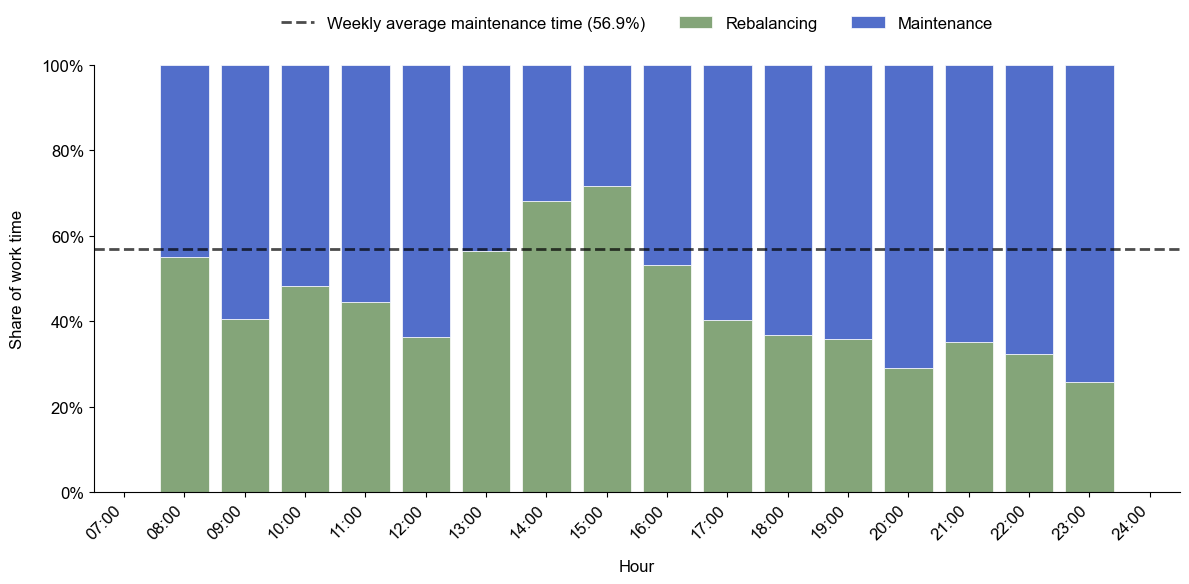

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_work_time_profile(df_hourly, title_label):
    """
    Plots the daily profile of work share (Rebalancing vs Maintenance)
    as a stacked percentage bar chart.
    """
    # ==========================================
    # 1. DATA PREPARATION
    # ==========================================

    # Filter out hours before 7 AM (if desired)
    hourly_df_filtered = df_hourly[df_hourly['Hour'] >= 7].copy()

    # Calculate raw minutes per hour
    # Assumption: 0.5 minutes per bike move (Pickup/Delivery)
    hourly_df_filtered['Rebalancing Time'] = (hourly_df_filtered['Bike Pickups'] + hourly_df_filtered['Bike Deliveries']) * 0.5
    hourly_df_filtered['Maintenance Time'] = hourly_df_filtered['Maintenance Time (minutes)']

    # Group by 'Hour' to find the average (across all days in the simulation)
    daily_profile = hourly_df_filtered.groupby("Hour")[['Rebalancing Time', 'Maintenance Time']].mean()

    # Re-calculate fractions
    daily_profile['Total Activity'] = daily_profile['Rebalancing Time'] + daily_profile['Maintenance Time']
    
    # Avoid division by zero
    daily_profile['Fraction Rebalancing'] = daily_profile.apply(
        lambda row: row['Rebalancing Time'] / row['Total Activity'] if row['Total Activity'] > 0 else 0, axis=1
    )
    daily_profile['Fraction Maintenance'] = daily_profile.apply(
        lambda row: row['Maintenance Time'] / row['Total Activity'] if row['Total Activity'] > 0 else 0, axis=1
    )

    # Fill NaNs and Sort
    daily_profile = daily_profile.fillna(0).sort_index()

    # Calculate weekly average percentage for maintenance
    total_rebalancing = daily_profile['Rebalancing Time'].sum()
    total_maintenance = daily_profile['Maintenance Time'].sum()
    total_work = total_rebalancing + total_maintenance
    
    if total_work > 0:
        weekly_avg_maintenance_pct = (total_maintenance / total_work) * 100
        weekly_avg_rebalancing_pct = (total_rebalancing / total_work) * 100
    else:
        weekly_avg_maintenance_pct = 0
        weekly_avg_rebalancing_pct = 0
    
    # Print the weekly averages
    print(f"\n{title_label}:")
    print(f"  Weekly Average Maintenance: {weekly_avg_maintenance_pct:.2f}%")
    print(f"  Weekly Average Rebalancing: {weekly_avg_rebalancing_pct:.2f}%")

    # ==========================================
    # 2. PLOTTING
    # ==========================================
    
    # Set safe defaults if variables aren't in scope
    local_font_size = 12

    # Set global font family
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

    hours = daily_profile.index
    color_maint = activity_colors["Maintenance"]      # Blue Accent
    color_rebal = activity_colors["Rebalance"]      # Muted Orange/Terra cotta

    # --- PLOT ---
    ax.bar(hours, daily_profile['Fraction Rebalancing'],
           color=color_rebal, label='Rebalancing',
           width=0.8, edgecolor='white', linewidth=0.5)

    ax.bar(hours, daily_profile['Fraction Maintenance'],
           bottom=daily_profile['Fraction Rebalancing'],
           color=color_maint, label='Maintenance',
           width=0.8, edgecolor='white', linewidth=0.5)

    # Add horizontal line for weekly average maintenance percentage
    weekly_avg_fraction = weekly_avg_maintenance_pct / 100
    ax.axhline(y=weekly_avg_fraction, color='#000000', linestyle='--', linewidth=2, 
               label=f'Weekly average maintenance time ({weekly_avg_maintenance_pct:.1f}%)', alpha=0.7)

    # --- AESTHETICS ---

    # Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("#000000")
    ax.spines['bottom'].set_color("#000000")

    # Grid
    #ax.grid(True, which='major', axis='y', linestyle='--', color='#DDDDDD', zorder=0, alpha=0.2)
    ax.grid(False, axis='x')

    # X-Axis Ticks
    ax.set_xticks(hours)
    ax.set_xticklabels([f"{int(h):02d}:00" for h in hours], 
                       rotation=45, color="#000000", ha="right", fontsize=local_font_size)

    # Y-Axis Ticks
    ax.set_yticks(np.linspace(0, 1.0, 6))
    ax.tick_params(axis='y', colors="#000000", labelsize=local_font_size)

    # Format Y-axis as percentage
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

    # Limits
    ax.set_ylim(0, 1.0)
    if not hours.empty:
        ax.set_xlim(hours.min()-0.5, hours.max()+0.5)

    # Labels
    ax.set_ylabel("Share of work time", fontsize=local_font_size, color="#000000", labelpad=12)
    ax.set_xlabel("Hour", fontsize=local_font_size, color="#000000", labelpad=12)

    # Legend
    ax.legend(frameon=False, fontsize=local_font_size, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.tight_layout()
    plt.savefig(
        f"daily_worktime_profile_{safe_label}_NEW.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Work Profile plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_work_time_profile(
        df_hourly=current_hourly_df,
        title_label=label_text
    )

# 6 - Vehicle insight

## 6.1 stastion to station flow

In [ ]:
# ---------------------------
# 1. ANALYSIS FUNCTION
# ---------------------------
def analyze_vehicle_transitions(df_vehicle, title_label, scale_factor=1):
    """
    Analyzes vehicle movements to find the most common 'From -> To' station transitions.
    """
    df = df_vehicle.copy()

    # Sort by vehicle and time to ensure correct sequence
    # Note: 'Seed' column might not exist if loading a single CSV, 
    # but grouping by 'Vehicle ID' is usually safe per file.
    if "Seed" in df.columns:
        df = df.sort_values(["Seed", "Vehicle ID", "Time (minutes)"])
        group_cols = ["Seed", "Vehicle ID"]
    else:
        df = df.sort_values(["Vehicle ID", "Time (minutes)"])
        group_cols = ["Vehicle ID"]

    # For each vehicle, shift Station ID to get "next" station
    df["Next Station ID"] = df.groupby(group_cols)["Station ID"].shift(-1)

    # Drop last visits (no "next" station)
    transitions = df.dropna(subset=["Next Station ID"]).copy()

    # Count how often each directed pair occurs
    transition_counts = (
        transitions
        .groupby(["Station ID", "Next Station ID"])
        .size()
        .reset_index(name="Count")
        .rename(columns={"Station ID": "From", "Next Station ID": "To"})
    )
    
    # Normalize count if this is an aggregate of multiple seeds
    if scale_factor > 1:
        transition_counts["Avg Count/Run"] = transition_counts["Count"] / scale_factor
        sort_col = "Avg Count/Run"
    else:
        sort_col = "Count"

    # Keep only strongest flows (top 10 edges)
    top_flows = transition_counts.sort_values(sort_col, ascending=False).head(10)
    
    # Formatting for display
    print(f"\n--- Top 10 Vehicle Transitions: {title_label} ---")
    if scale_factor > 1:
        # Use round(1) to keep the display clean but accurate
        display_df = top_flows[["From", "To", "Avg Count/Run"]].copy()
        display_df["Avg Count/Run"] = display_df["Avg Count/Run"].round(1)
        print(display_df.to_string(index=False))
    else:
        print(top_flows[["From", "To", "Count"]].to_string(index=False))

    return top_flows

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"\n{'='*20} VEHICLE ROUTE ANALYSIS COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Determine Scale Factor
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str)
        scale = len(seeds_used)
    else:
        scale = 1
        
    # 2. Get Data
    df_vehicle = data_dict["vehicle"]
    
    # 3. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 4. Analyze
    analyze_vehicle_transitions(
        df_vehicle=df_vehicle,
        title_label=label_text,
        scale_factor=scale
    )

print("="*60)


==================== VEHICLE ROUTE ANALYSIS COMPARISON ====================
Aggregation Mode: average
DEBUG: Found seeds for alpha 0.250: [1, 2, 3, 4]

--- Top 10 Vehicle Transitions: Alpha 0.25 (average) ---
From  To  Avg Count/Run
 S31 S66            7.2
 S60 S41            4.5
 S63 S43            4.0
  S4 S37            4.0
 S41 S41            3.8
 S46 S63            3.8
 S37 S37            3.8
 S60 S31            3.5
 S31 S60            3.5
 S61 S31            3.2


## 6.2 Vehicle decision logic


In [ ]:
# ---------------------------
# 1. CHRONOLOGICAL COMPARISON FUNCTION
# ---------------------------
def compare_decisions_chronologically(alpha_list, seed_to_compare):
    """
    Loads data for a specific seed across all Alphas, aligns vehicle movements 
    by sequence step, and prints them side-by-side to find divergence.
    """
    print(f"Aligning chronological sequences for Seed {seed_to_compare} across {len(alpha_list)} Alphas...")
    
    # List to hold the sequence for each Alpha
    all_sequences = []

    # 1. Extract Sequence for every Alpha
    for alpha_val in alpha_list:
        alpha_str = f"{alpha_val:.3f}"
        
        # We RE-LOAD the specific single seed to ensure we have clean, un-stacked data
        # (Using the helper function defined in previous cells)
        try:
            data = load_single_seed(seed_to_compare, alpha_str)
            df = data["vehicle"].copy()
        except Exception as e:
            print(f"Skipping Alpha {alpha_val}: {e}")
            continue

        # Sort to ensure chronological order
        if "Vehicle ID" in df.columns:
            df = df.sort_values(["Vehicle ID", "Time (minutes)"])
            # Create a "Step" counter (1, 2, 3...) for each vehicle
            df["Step"] = df.groupby("Vehicle ID").cumcount() + 1
            df["Vehicle_Step"] = df["Vehicle ID"].astype(str) + "_Step_" + df["Step"].astype(str).str.zfill(3)
        else:
            # Fallback for single vehicle without ID
            df = df.sort_values("Time (minutes)")
            df["Step"] = range(1, len(df) + 1)
            df["Vehicle_Step"] = "V0_Step_" + df["Step"].astype(str).str.zfill(3)
            
        # Select just the columns we need
        # We store the Station ID as the value, column name = Alpha
        col_name = f"Alpha {alpha_val}"
        seq_df = df[["Vehicle_Step", "Station ID"]].rename(columns={"Station ID": col_name})
        seq_df = seq_df.set_index("Vehicle_Step")
        
        all_sequences.append(seq_df)

    # 2. Merge into one Master Timeline
    if not all_sequences:
        print("No sequences found.")
        return

    # Outer join aligns them by Step Number
    timeline = pd.concat(all_sequences, axis=1)
    
    # Sort index to ensure Step 1 comes before Step 2
    timeline = timeline.sort_index()

    # 3. Analyze Divergence
    # Check if all columns in a row have the same value
    first_col = timeline.columns[0]
    
    # Logic: Are all Alpha columns equal to the first Alpha column?
    is_match = timeline.fillna("MISSING").eq(timeline[first_col].fillna("MISSING"), axis=0).all(axis=1)
    
    timeline["Status"] = np.where(is_match, "Match", "[!] DIVERGENCE")

    # 4. PRINTING
    print("\n" + "="*100)
    print(f"CHRONOLOGICAL DECISION TIMELINE (Seed {seed_to_compare})")
    print(f"Tracking sequence of stations visited across different Alphas.")
    print("="*100)
    
    # Adjust display options
    pd.set_option('display.max_rows', 500)
    pd.set_option('display.max_columns', 50)
    pd.set_option('display.width', 1000)
    
    # Show the table (filling NaNs for readability)
    display_df = timeline.fillna("-")
    print(display_df)
    
    print("="*100)
    
    # Summary of Stability
    total_steps = len(timeline)
    divergent_steps = len(timeline[timeline["Status"] == "[!] DIVERGENCE"])
    
    print(f"Total Steps Compared: {total_steps}")
    print(f"Divergent Steps:      {divergent_steps}")
    
    if total_steps > 0:
        match_pct = (1 - divergent_steps/total_steps) * 100
        print(f"Policy Similarity:    {match_pct:.1f}%")

        # Find FIRST divergence
        divergence_idx = timeline.index[timeline["Status"] == "[!] DIVERGENCE"]
        if not divergence_idx.empty:
            print(f"First Policy Divergence occurs at: {divergence_idx[0]}")
    
    # Reset options
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')

    return timeline

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

# We need to pick a representative seed.
# If we are in 'Single' mode (int), use that.
# If we are in 'Average' mode, pick the first available seed from the folder.
if isinstance(selection_mode, int):
    target_seed = selection_mode
else:
    # Scan for available seeds using the first alpha as a reference
    first_alpha = f"{alpha_values[0]:.3f}"
    seeds = get_available_seeds(first_alpha)
    if seeds:
        target_seed = seeds[0] # Pick the first one
    else:
        target_seed = None
        print("Error: No seeds found to compare.")

if target_seed is not None:
    chronological_table = compare_decisions_chronologically(
        alpha_list=list(alpha_results.keys()), # Use keys from your loaded results
        seed_to_compare=target_seed
    )

DEBUG: Found seeds for alpha 0.250: [1, 2, 3, 4]
Aligning chronological sequences for Seed 1 across 1 Alphas...

CHRONOLOGICAL DECISION TIMELINE (Seed 1)
Tracking sequence of stations visited across different Alphas.
             Alpha 0.25 Status
Vehicle_Step                  
V0_Step_001          S0  Match
V0_Step_002         S21  Match
V0_Step_003          S0  Match
V0_Step_004         S11  Match
V0_Step_005         S42  Match
V0_Step_006         S35  Match
V0_Step_007         S57  Match
V0_Step_008          S1  Match
V0_Step_009         S29  Match
V0_Step_010         S50  Match
V0_Step_011         S29  Match
V0_Step_012         S10  Match
V0_Step_013         S53  Match
V0_Step_014         S52  Match
V0_Step_015         S37  Match
V0_Step_016         S18  Match
V0_Step_017         S64  Match
V0_Step_018         S60  Match
V0_Step_019         S61  Match
V0_Step_020         S62  Match
V0_Step_021         S40  Match
V0_Step_022         S55  Match
V0_Step_023         S32  Match
V0_Step_

# Computational time analysis


### Analyzing runtimes across alpha values

In [ ]:
import re

def get_final_run_times(filepath):
    """
    Parser loggfilen og henter ut siste tid (f.eks 19s) før hver simulering avsluttes.
    """
    saved_times = []
    current_val = None
    
    # Regex som finner tall + 's' på slutten av linjen (f.eks "19s" eller "1.2s")
    time_pattern = re.compile(r'\s(\d+(?:\.\d+)?)s$')

    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                stripped = line.strip()

                # 1. Oppdater "nåværende" tid hvis vi ser en linje som slutter på 's'
                match = time_pattern.search(stripped)
                if match:
                    current_val = float(match.group(1))

                # 2. Sjekk om blokken er ferdig (Se etter "Explored ... nodes")
                # Dette markerer at Gurobi er ferdig med selve søket.
                if stripped.startswith("Explored") and "seconds" in stripped:
                    if current_val is not None:
                        saved_times.append(current_val)
                        current_val = None # Nullstill for neste runde
                
                # Sikkerhetsnett: Noen ganger kommer "Solution count" rett etterpå
                elif stripped.startswith("Solution count") and current_val is not None:
                     saved_times.append(current_val)
                     current_val = None

        return saved_times

    except FileNotFoundError:
        return "Error: File not found."

# --- KJØR SCRIPTET ---
path = r"C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\log_files\fullweek_TD_A025_Timehorizon7_S1_1312250951.txt"

final_times = get_final_run_times(path)

if isinstance(final_times, list) and len(final_times) > 0:
    print(f"Fant totalt {len(final_times)} kjøringer.")
    print("-" * 30)
    print("De første 5 verdiene:", final_times[:5])
    print("De siste 5 verdiene :", final_times[-5:])
    print("-" * 30)
    
    # --- BEREGN GJENNOMSNITT ---
    average_time = sum(final_times) / len(final_times)
    print(f"Gjennomsnittlig kjøretid: {average_time:.2f} sekunder")

elif isinstance(final_times, list) and len(final_times) == 0:
    print("Fant ingen tider. Sjekk at loggfilen inneholder linjer som slutter på 's'.")
else:
    print(final_times) # Printer feilmelding hvis filen ikke finnes

Error: File not found.


### Runtime as a function of time horizons


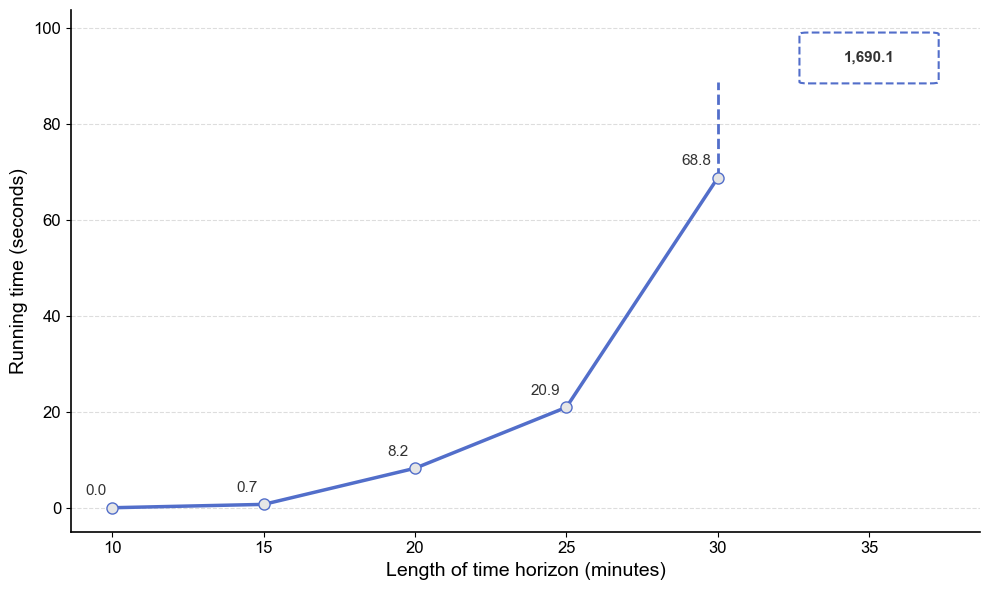

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Data
running_times = [0.0, 0.7, 8.23, 20.94, 68.76, 1690.12]
alpha_values_to_test = [2, 3, 4, 5, 6, 7]
time_horizons_minutes = [t * 5 for t in alpha_values_to_test]

# Plot only first 5 points
x_plot = time_horizons_minutes[:5]
y_plot = running_times[:5]

# Last point information (for the box)
x_last = time_horizons_minutes[-1]
y_last = running_times[-1]

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 6))

color_line = "#526ECA"
marker_fill = "#E6E6E6"

# Plot the main curve (first 5 points)
ax.plot(x_plot, y_plot, marker='o', linestyle='-', linewidth=2.5, 
        color=color_line, markerfacecolor=marker_fill, markeredgecolor=color_line, 
        markersize=8, zorder=10)

# Add dashed line going upward from last plotted point
ax.plot([x_plot[-1], x_plot[-1]], [y_plot[-1], y_plot[-1] + 20], 
        linestyle='--', linewidth=2, color=color_line, zorder=5)

# Add dashed box with the outlier value at top
box_x = x_last
box_y = max(y_plot) + 25
box_text = f"{y_last:,.1f}"

# Create dashed rectangle
rect = mpatches.FancyBboxPatch((box_x - 2, box_y - 5), 4, 10, 
                                boxstyle="round,pad=0.3", 
                                linewidth=1.5, edgecolor=color_line, 
                                facecolor='white', linestyle='--', zorder=15)
ax.add_patch(rect)

# Add text inside the box
ax.text(box_x, box_y, box_text, ha='center', va='center', 
        color='#333333', fontsize=11, fontweight='bold', zorder=20)

# Aesthetics
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.grid(True, which='major', axis='y', linestyle='--', color='#DDDDDD', zorder=0)
ax.tick_params(axis='both', which='major', labelsize=12)

# Labels
ax.set_xlabel("Length of time horizon (minutes)", fontsize=14)
ax.set_ylabel("Running time (seconds)", fontsize=14)
ax.set_xticks(time_horizons_minutes)

# Adjust y-limit to accommodate the box
ax.set_ylim(-5, box_y + 10)

# Annotations for the plotted points
for x, y in zip(x_plot, y_plot):
    ax.text(x - 0.2, y + 2, f"{y:,.1f}", ha='right', va='bottom', 
            color='#333333', fontsize=11)

plt.tight_layout()
plt.savefig("running_time_with_outlier_box.svg", bbox_inches='tight', pad_inches=0.02)
plt.show()

# Long Congestions Retrieval

In [ ]:
def get_long_congestions(seed: int, alpha: float, experiment_folder_path: Path = results_dir_root) -> float:
    """
    Retrieves the 'Long Congestions' value from summary statistics file.
    
    Parameters:
    -----------
    seed : int
        The seed number to retrieve data for
    alpha : float
        The alpha value (will be formatted as 3-decimal string, e.g., 0.250)
    experiment_folder_path : Path
        Path to the experiment folder (defaults to results_dir_root from config)
        
    Returns:
    --------
    float : The Long Congestions value
    """
    alpha_str = f"{alpha:.3f}"
    pattern = f"*seed_{seed}_alpha01-05_fullweek_{alpha_str}_results.csv"
    matches = list(experiment_folder_path.glob(pattern))
    
    if not matches:
        raise FileNotFoundError(f"No summary statistics file found matching: {pattern}")
    
    # Read the summary statistics file
    summary_df = pd.read_csv(matches[0])
    
    # Check if 'Long Congestions' column exists
    if 'Long Congestions' not in summary_df.columns:
        raise ValueError(f"'Long Congestions' column not found in {matches[0].name}")
    
    # Return the value (assuming single row summary)
    return summary_df['Long Congestions'].iloc[0]


def get_long_congestions_by_mode(alpha: float, mode, available_seeds_list: list = None) -> dict:
    """
    Retrieves Long Congestions data based on selection mode.
    
    Parameters:
    -----------
    alpha : float
        The alpha value to retrieve data for
    mode : str or int
        - "average": Returns average across all available seeds
        - int: Returns value for specific seed number
    available_seeds_list : list, optional
        List of available seeds. If None, will auto-detect for the given alpha
        
    Returns:
    --------
    dict : Dictionary with 'mode', 'alpha', 'value', and optionally 'seeds' used
    """
    alpha_str = f"{alpha:.3f}"
    
    # Get available seeds if not provided
    if available_seeds_list is None:
        available_seeds_list = get_available_seeds(alpha_str)
    
    if not available_seeds_list:
        raise ValueError(f"No seeds found for alpha {alpha}")
    
    result = {
        'alpha': alpha,
        'mode': mode
    }
    
    if mode == "average":
        # Get congestions for all seeds and calculate average
        congestion_values = []
        for seed in available_seeds_list:
            try:
                value = get_long_congestions(seed, alpha)
                congestion_values.append(value)
            except FileNotFoundError as e:
                print(f"Warning: Could not find file for seed {seed}: {e}")
        
        if not congestion_values:
            raise ValueError(f"No valid congestion data found for alpha {alpha}")
        
        result['value'] = np.mean(congestion_values)
        result['std'] = np.std(congestion_values)
        result['seeds_used'] = available_seeds_list
        result['seed_values'] = congestion_values
        
    elif isinstance(mode, int):
        # Get congestions for specific seed
        if mode not in available_seeds_list:
            raise ValueError(f"Seed {mode} not available for alpha {alpha}. Available: {available_seeds_list}")
        
        result['value'] = get_long_congestions(mode, alpha)
        result['seed'] = mode
    
    else:
        raise ValueError(f"Invalid mode: {mode}. Must be 'average' or an integer seed number")
    
    return result


# Example usage:
print("Long Congestions Retrieval Functions Defined")
print("\nExample Usage:")
print("1. Single seed: get_long_congestions(seed=1, alpha=0.250)")
print("2. By mode: get_long_congestions_by_mode(alpha=0.250, mode='average')")
print("3. Specific seed via mode: get_long_congestions_by_mode(alpha=0.250, mode=1)")


Long Congestions Retrieval Functions Defined

Example Usage:
1. Single seed: get_long_congestions(seed=1, alpha=0.250)
2. By mode: get_long_congestions_by_mode(alpha=0.250, mode='average')
3. Specific seed via mode: get_long_congestions_by_mode(alpha=0.250, mode=1)


In [ ]:
# Retrieve Long Congestions for configured alpha values and selection mode
print(f"Retrieving Long Congestions data...")
print(f"Alpha values: {alpha_values}")
print(f"Selection mode: {selection_mode}\n")

congestion_results = {}

for alpha in alpha_values:
    print(f"--- Alpha {alpha} ---")
    try:
        result = get_long_congestions_by_mode(alpha=alpha, mode=selection_mode)
        congestion_results[alpha] = result
        
        if selection_mode == "average":
            print(f"  Long Congestions (Average): {result['value']:.2f}")
            print(f"  Standard Deviation: {result['std']:.2f}")
            print(f"  Number of seeds: {len(result['seeds_used'])}")
            print(f"  Individual values: {[f'{v:.2f}' for v in result['seed_values']]}")
        else:
            print(f"  Long Congestions (Seed {selection_mode}): {result['value']:.2f}")
    except Exception as e:
        print(f"  Error: {e}")
    print()

# Store in a summary format
print("\n=== Summary ===")
for alpha, result in congestion_results.items():
    if selection_mode == "average":
        print(f"Alpha {alpha}: {result['value']:.2f} ± {result['std']:.2f}")
    else:
        print(f"Alpha {alpha} (Seed {selection_mode}): {result['value']:.2f}")


Retrieving Long Congestions data...
Alpha values: [0.0]
Selection mode: average

--- Alpha 0.0 ---
DEBUG: Found seeds for alpha 0.000: [1, 2, 3, 4]
  Long Congestions (Average): 513.67
  Standard Deviation: 65.74
  Number of seeds: 4
  Individual values: ['512.00', '595.00', '434.00']


=== Summary ===
Alpha 0.0: 513.67 ± 65.74
